In [498]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [499]:
task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_proxy, device_controller]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

In [500]:
borg_cr = "How physically challenging was the experience?"
sp_fatigue = "How fatigued where you after the experience?"

general_1 = "I felt the weight of the object, while i was grabbing it"
general_2 = "The weight of the object, while i was grabbing it, felt realistic"
general_custom = [general_1, general_2]

shovel_1 = "I felt the weight of the shovel increasing when loading it"
shovel_2 = "I felt the weight of the shovel decreasing when unloading it"
shovel_3 = "After the shovel had been loaded, it required more effort to manipulate"
shovel_4 = "After the shovel had been unloaded, it required less effort to manipulate"
shovel_custom = [shovel_1, shovel_2, shovel_3, shovel_4]

fps_1 = "  My sense of being in the virtual world was like being in a real place."
fps_2 = "During the experience, I felt the virtual world was reality for me. "
fps_3 = "I felt like I was actually there in the virtual world. "
fps_4 = "I felt present in the virtual world. "
fps_5 = "I felt I could control my actions within the virtual world. "
fps_6 = "I felt the virtual world was responsive to my actions. "
fps_7 = "I felt I could move or manipulate objects easily in the virtual world. "
fps_8 = "I felt involved in the virtual world experience. "
fps_9 = "I could concentrate on the virtual activities rather than the controls to perform them. "
fps_10 = "When something happened to my virtual body, I felt it happened to my real body. "
fps = [fps_1, fps_2, fps_3, fps_4, fps_5, fps_6, fps_7, fps_8, fps_9, fps_10]

relevant_keys = [condition_key, task, borg_cr, sp_fatigue] + general_custom + shovel_custom + fps

In [501]:
def get_df(name):
    path = './questionnaires/' + name + '.csv'
    return pd.read_csv(path)

In [502]:
data = get_df('experiments').filter(items=relevant_keys)

data[device_key] = data[condition_key].str[0]
data[scaling_key] = data[condition_key].str[1:]

data.insert(0, 'No', range(0, 0 + len(data)))
data[subject_key] = data.apply(lambda x: int(x['No'] / 12) + 1, axis=1)

data.tail(3)

,No,Condition,Task,How physically challenging was the experience?,How fatigued where you after the experience?,"I felt the weight of the object, while i was grabbing it","The weight of the object, while i was grabbing it, felt realistic",I felt the weight of the shovel increasing when loading it,I felt the weight of the shovel decreasing when unloading it,"After the shovel had been loaded, it required more effort to manipulate",...,I felt present in the virtual world.,I felt I could control my actions within the virtual world.,I felt the virtual world was responsive to my actions.,I felt I could move or manipulate objects easily in the virtual world.,I felt involved in the virtual world experience.,I could concentrate on the virtual activities rather than the controls to perform them.,"When something happened to my virtual body, I felt it happened to my real body.",Device,Scaling,Subject
501,501,C1,Shovel,1 - Very light,1 - Very alert and fully awake,2,1,1.0,1.0,2.0,...,5,5,5,3,4,3,3,C,1,42
502,502,C2,Shovel,1 - Very light,1 - Very alert and fully awake,3,1,1.0,1.0,1.0,...,5,4,5,3,4,2,3,C,2,42
503,503,P2,Shovel,1 - Very light,1 - Very alert and fully awake,7,7,2.0,2.0,2.0,...,5,5,3,6,4,7,3,P,2,42


In [503]:
significance_key = "Significance"
aov_key = "aov"
pairwise_key = "pairwise"
eff_size_key = "ng2"

def get_significant_entries(df):
    return df[df[significance_key] == "✅"]

def get_semi_significant_entries(df):
    return df[df[significance_key] != "❌"]

def rm_anova(df, value_key, two_way):
    within = [device_key, scaling_key] if two_way else condition_key

    aov = pg.rm_anova(
        dv=value_key,
        within=within,
        subject=subject_key,
        data=df,
        detailed=True
    )

    p_unc = "p-unc"
    p_corr = "p-GG-corr"
    aov[significance_key] = aov.apply(lambda x:
        "✅" if
            (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    display(aov)

    pairwise = pg.pairwise_tests(
    dv=value_key,
    within=within,
    subject=subject_key,
    data=df,
    padjust='holm'
    )

    p_unc = "p-unc"
    p_corr = "p-corr"
    pairwise[significance_key] = pairwise.apply(lambda x:
        "✅" if
            (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    significant_sources = get_significant_entries(aov).get("Source").tolist()
    valid_pairwise = pairwise[pairwise["Contrast"].isin(significant_sources)]

    if(valid_pairwise.shape[0] > 0):
        display(valid_pairwise)

    return {
        aov_key: aov,
        pairwise_key: valid_pairwise
    }

In [504]:
#Adapted from https://stackoverflow.com/questions/11517986/indicating-the-statistically-significant-difference-in-bar-graph
def barplot_annotate_brackets(ax, num1, num2, data, x, y, offset, height, addtext='', color="black", fs=None, maxasterix=3):
    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = x[num1], y[num1]
    rx, ry = x[num2], y[num2]

    y = max(ly, ry) + offset

    barx = [lx, lx, rx, rx]
    bary = [y, y+height, y+height, y]
    mid = ((lx+rx)/2, y+height)

    ax.plot(barx, bary, c=color)

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    if addtext != "":
        text = text + " (" + addtext + ")"

    ax.text(*mid, text, color=color, **kwargs)

In [505]:
condition_dict = {'C0': 0, 'C1': 1, 'C2': 2, 'P0': 3, 'P1': 4, 'P2': 5}

def get_confidence_interval(values):
    return 1.96 * np.std(values) / np.sqrt(len(values))

def plot_significance_brackets(ax, scale, barheights, brackets):
    n_bars = np.arange(len(conditions))

    offset_step = (scale[1] - scale[0]) / 5
    bracket_height = offset_step * 0.25
    fixed_heights =  [np.max(barheights) + bracket_height*2] * len(conditions)

    current_offset = 0

    for bracket in brackets:
        barplot_annotate_brackets(ax, bracket[0], bracket[1], bracket[2], n_bars, fixed_heights, offset= current_offset, height=bracket_height)
        current_offset += offset_step

    # Set axis limits to provided scale or max bracket height if higher
    ax.set_ylim([scale[0], np.max([fixed_heights[0]+current_offset, scale[1]])])

def plot_values(axs, idx, values, labels, scale, title, brackets, clrs=colors):
    means = list(map(lambda x: np.mean(x), values))
    conf = list(map(get_confidence_interval, values))

    axs[idx, 0].bar(labels, means, color=clrs)
    axs[idx, 0].errorbar(labels, means, yerr= conf, fmt='none', capsize=6, color="black")
    axs[idx, 0].set_title(title + ' Mean (+CI)')
    axs[idx, 0].set_yticks(range(scale[0], scale[1]+1))

    barheights = []
    for i in range(len(labels)):
        barheights.append(means[i] + conf[i])

    plot_significance_brackets(axs[idx, 0], scale, barheights, brackets)

    n_bars = np.arange(len(labels))

    axs[idx, 1].violinplot(values, showmeans=True)
    axs[idx, 1].set_title(title + ' Violin (+Mean)')
    axs[idx, 1].set_ylim([scale[0]-0.5, scale[1]+0.5])
    axs[idx, 1].set_xticks([y + 1 for y in n_bars], labels=labels)

    axs[idx, 2].boxplot(values, tick_labels=labels)
    axs[idx, 2].set_title(title + ' Boxplot')
    axs[idx, 2].set_ylim([scale[0]-0.5, scale[1]+0.5])

def plot_experiment(df, e, key, title, scale, two_way_tests, one_way_tests):
    fig, axs = plt.subplots(3, 3, figsize=(20, 10))
    fig.suptitle('[' + e + '] ' + title)

    device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    device_brackets = []
    device_test = two_way_tests.loc[(two_way_tests['Contrast'] == device_key)]
    for index, row in device_test.iterrows():
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        device_brackets.append([0,1,p_value])
    plot_values(axs, 0, device_values, devices, scale, "Device", brackets=device_brackets, clrs=["tab:blue", "tab:red"])

    scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    scaling_brackets = []
    scaling_test = two_way_tests.loc[(two_way_tests['Contrast'] == scaling_key)]
    for index, row in scaling_test.iterrows():
        a = int(row["A"])
        b = int(row["B"])
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        scaling_brackets.append([a,b,p_value])
    plot_values(axs, 1, scaling_values, scalings, scale, "Scaling", brackets=scaling_brackets)

    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    condition_brackets = []
    for index, row in one_way_tests.iterrows():
        a = condition_dict[row["A"]]
        b = condition_dict[row["B"]]
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        condition_brackets.append([a,b,p_value])
    plot_values(axs, 2, condition_values, conditions, scale, "Condition", brackets=condition_brackets)

    fig.tight_layout()
    plt.show()


In [506]:
cube_aovs = []
shovel_aovs = []
aovs_dv_key = "key"
two_way_key = "two_way"
one_way_key = "one_way"

def try_add_aov_entry(new_entry, e):
    if e == cube and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in cube_aovs):
        cube_aovs.append(new_entry)
    elif e == shovel and not any(x[aovs_dv_key] == new_entry[aovs_dv_key] for x in shovel_aovs):
        shovel_aovs.append(new_entry)

def report_exeriment(data, e, key, title, scale):
    df = data[data[task] == e]

    print('\033[1m' + "------ " + "["+e+"] " + title + ": Two-Way RM ANOVA"  + " ------")
    two_way_result = rm_anova(df, key, two_way=True)
    print('\033[1m' + "------ " + "["+e+"] " + title + ": One-Way RM ANOVA"  + " ------")
    one_way_result = rm_anova(df, key, two_way=False)

    aov_entry = {
        aovs_dv_key: title,
        two_way_key: two_way_result[aov_key],
        one_way_key: one_way_result[aov_key]
    }
    try_add_aov_entry(aov_entry, e)

    two_way_sig_pairwise = get_significant_entries(two_way_result[pairwise_key])
    one_way_sig_pairwise = get_significant_entries(one_way_result[pairwise_key])

    plot_experiment(df, e, key, title, scale, two_way_sig_pairwise, one_way_sig_pairwise)

------ [Cube] FPS Total Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,4.426825,1,41,4.426825,14.084486,0.000542,0.000542,0.022965,1.000000,✅
1,Scaling,1.721667,2,82,0.860833,7.364458,0.001144,0.001338,0.009059,0.963042,✅
2,Device * Scaling,0.183889,2,82,0.091944,0.886704,0.415925,0.407850,0.000975,0.912055,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.752930,41.0,two-sided,0.000542,NaN,NaN,52.009,-0.315717,✅
1,Scaling,-,0,1,True,True,2.855850,41.0,two-sided,0.006708,0.013415,holm,5.647,0.171268,✅
2,Scaling,-,0,2,True,True,3.384854,41.0,two-sided,0.001579,0.004738,holm,20.04,0.240954,✅
3,Scaling,-,1,2,True,True,1.028305,41.0,two-sided,0.309835,0.309835,holm,0.273,0.060756,❌


------ [Cube] FPS Total Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,6.332381,5,1.266476,8.382037,3.125638e-07,0.000013,0.032529,0.690842,False,0.374678,0.000463,✅
1,Error,30.974286,205,0.151094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,1.218157,41.0,two-sided,0.230128,0.784514,holm,0.332,0.093518,❌
1,Condition,C0,C2,True,True,2.596295,41.0,two-sided,0.013022,0.104179,holm,3.199,0.211295,❌
2,Condition,C0,P0,True,True,-4.232705,41.0,two-sided,0.000127,0.001775,holm,193.562,-0.374789,✅
3,Condition,C0,P1,True,True,-1.443287,41.0,two-sided,0.156537,0.782686,holm,0.436,-0.118584,❌
4,Condition,C0,P2,True,True,-1.314068,41.0,two-sided,0.196128,0.784514,holm,0.371,-0.124379,❌
5,Condition,C1,C2,True,True,1.267416,41.0,two-sided,0.212158,0.784514,holm,0.351,0.114961,❌
6,Condition,C1,P0,True,True,-3.772498,41.0,two-sided,0.000512,0.006653,holm,54.793,-0.463123,✅
7,Condition,C1,P1,True,True,-1.832927,41.0,two-sided,0.074082,0.518572,holm,0.768,-0.203481,❌
8,Condition,C1,P2,True,True,-1.824403,41.0,two-sided,0.075384,0.518572,holm,0.757,-0.215014,❌
9,Condition,C2,P0,True,True,-4.915233,41.0,two-sided,0.000015,0.000221,holm,1391.678,-0.585952,✅


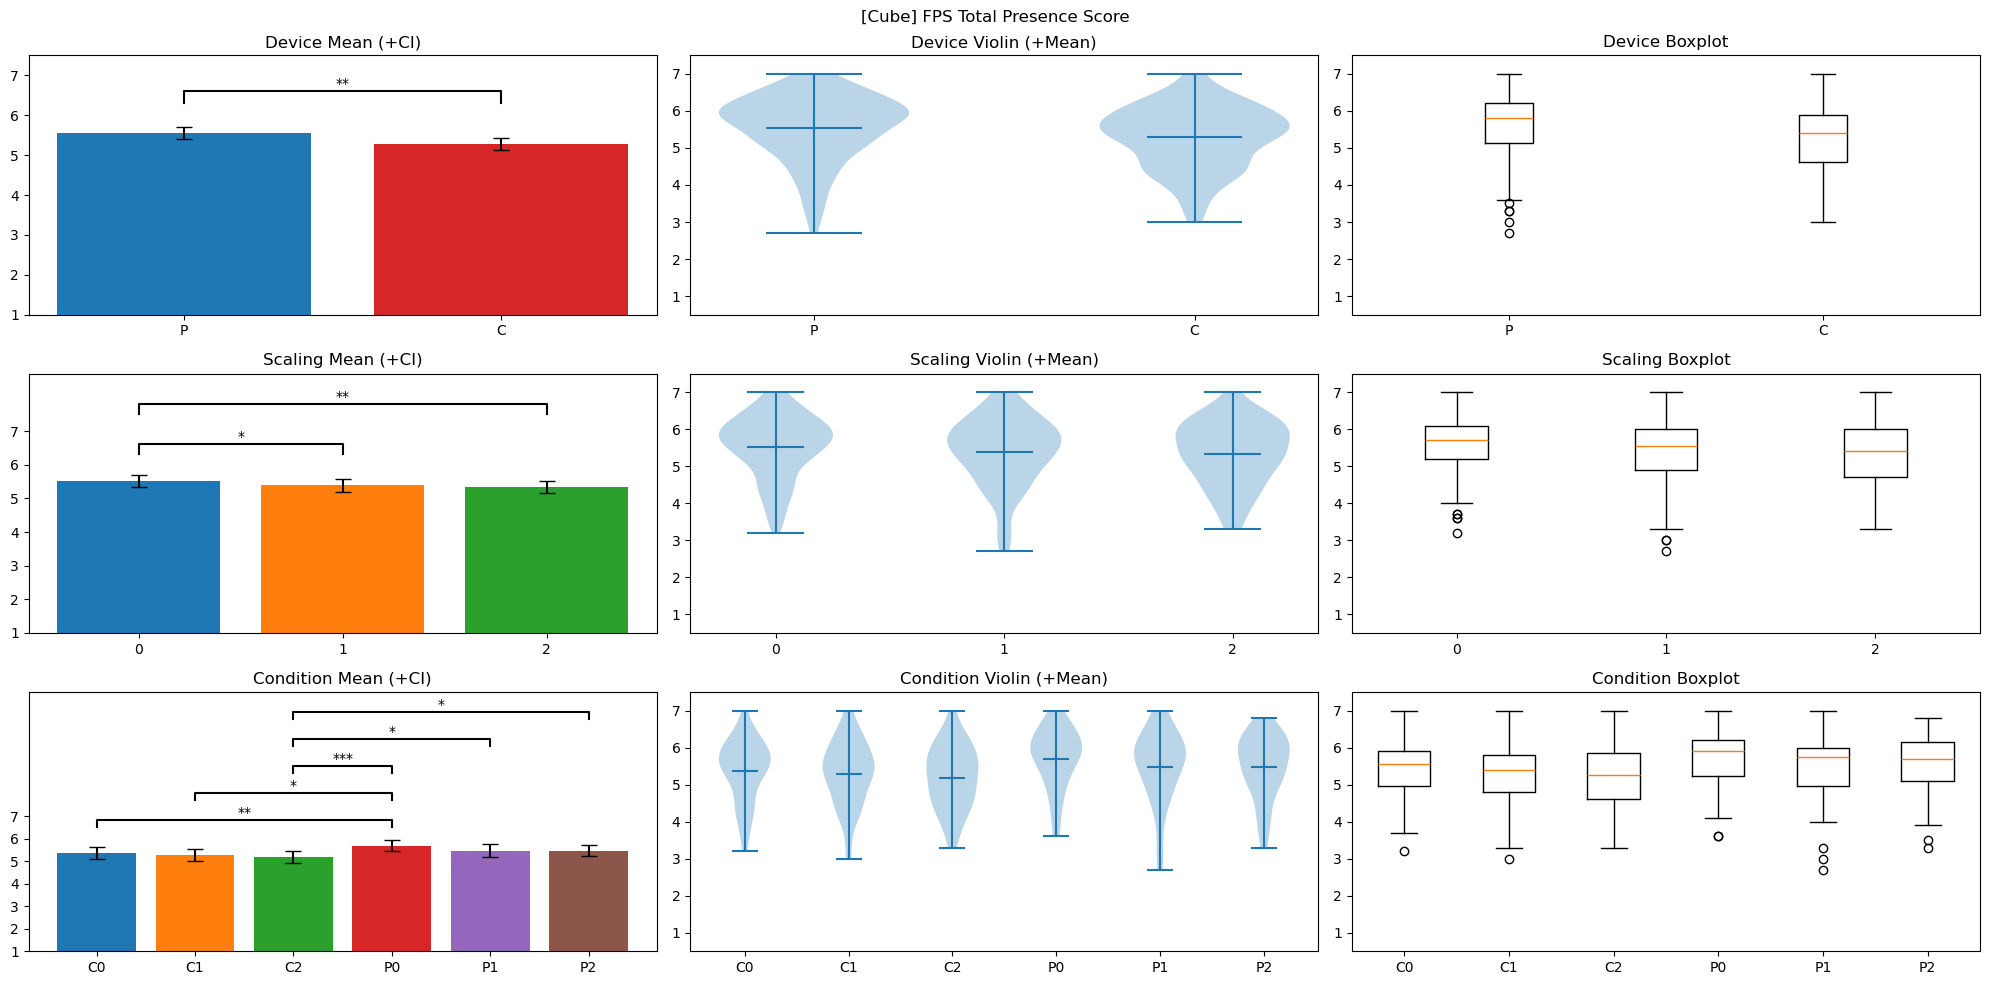

------ [Shovel] FPS Total Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,8.000040,1,41,8.000040,13.310875,0.000738,0.000738,0.041843,1.000000,✅
1,Scaling,4.818810,2,82,2.409405,9.571696,0.000184,0.000446,0.025631,0.849113,✅
2,Device * Scaling,0.341032,2,82,0.170516,0.758576,0.471591,0.471565,0.001858,0.999785,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.648407,41.0,two-sided,0.000738,NaN,NaN,39.46,-0.461301,✅
1,Scaling,-,0,1,True,True,2.056606,41.0,two-sided,0.046125,0.074067,holm,1.119,0.197769,🟨
2,Scaling,-,0,2,True,True,4.781158,41.0,two-sided,0.000023,0.000068,holm,937.501,0.430108,✅
3,Scaling,-,1,2,True,True,2.155623,41.0,two-sided,0.037033,0.074067,holm,1.338,0.248632,🟨


------ [Shovel] FPS Total Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,13.159881,5,2.631976,8.468243,2.645578e-07,0.000007,0.067023,0.733529,False,0.433506,0.00325,✅
1,Error,63.715119,205,0.310805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.567380,41.0,two-sided,5.735500e-01,1.000000,holm,0.194,0.076218,❌
1,Condition,C0,C2,True,True,3.588565,41.0,two-sided,8.790729e-04,0.011428,holm,33.751,0.361051,✅
2,Condition,C0,P0,True,True,-3.244565,41.0,two-sided,2.343842e-03,0.023438,holm,14.139,-0.510680,✅
3,Condition,C0,P1,True,True,-1.332323,41.0,two-sided,1.901124e-01,0.950562,holm,0.379,-0.221196,❌
4,Condition,C0,P2,True,True,-0.595371,41.0,two-sided,5.548677e-01,1.000000,holm,0.197,-0.083573,❌
5,Condition,C1,C2,True,True,2.251941,41.0,two-sided,2.974612e-02,0.208223,holm,1.601,0.300015,❌
6,Condition,C1,P0,True,True,-4.242716,41.0,two-sided,1.228993e-04,0.001721,holm,199.088,-0.601918,✅
7,Condition,C1,P1,True,True,-1.840929,41.0,two-sided,7.287623e-02,0.437257,holm,0.778,-0.298595,❌
8,Condition,C1,P2,True,True,-0.984057,41.0,two-sided,3.308593e-01,1.000000,holm,0.262,-0.158982,❌
9,Condition,C2,P0,True,True,-5.854341,41.0,two-sided,6.971075e-07,0.000010,holm,2.366e+04,-0.817664,✅


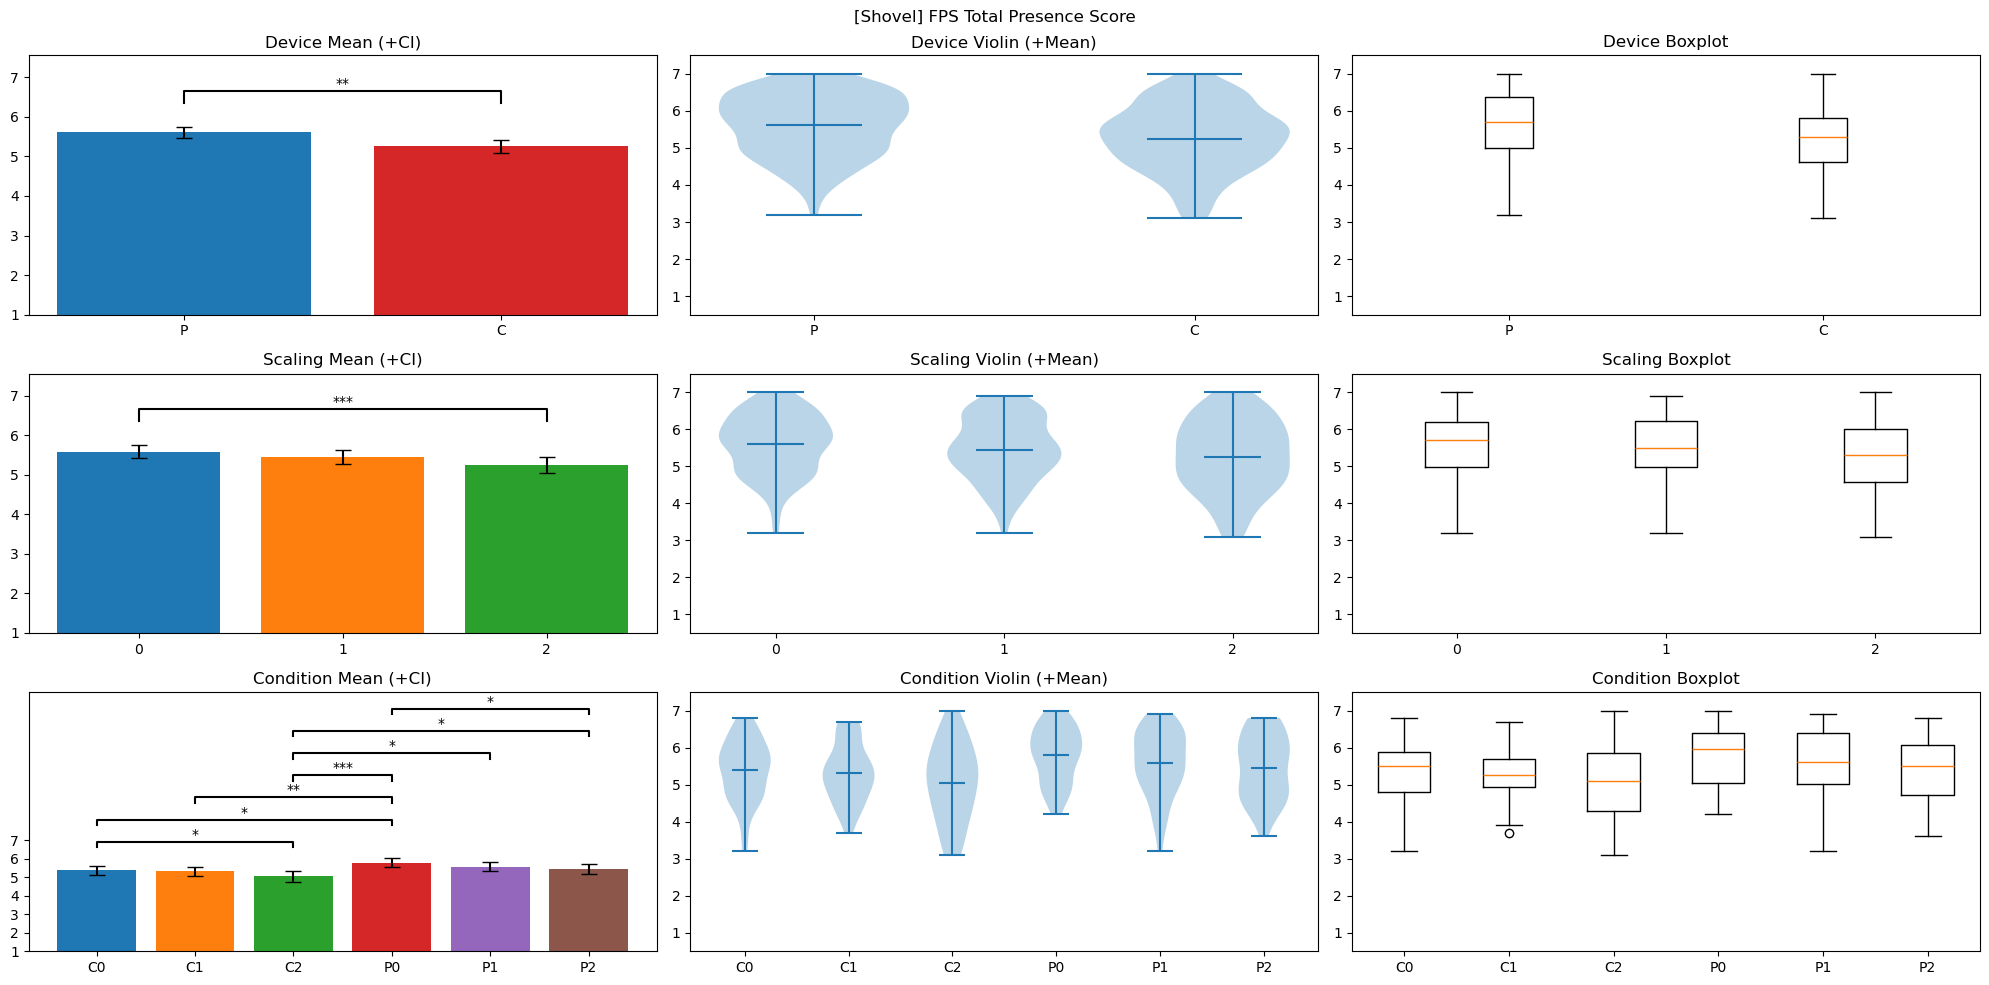

In [507]:
fps_total = 'fps_total'
#Total Presence Score: (FPS1-10) / 10
data[fps_total] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9] + x[fps_10]) / 10,
    axis = 1)

title = 'FPS Total Presence Score'
score = fps_total
scale = [1,7]
report_exeriment(data, cube, score, title, scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Interaction Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,3.055804,1,41,3.055804,9.148981,0.004282,0.004282,0.017454,1.000000,✅
1,Scaling,2.226314,2,82,1.113157,8.588649,0.000411,0.000470,0.012777,0.973888,✅
2,Device * Scaling,0.091890,2,82,0.045945,0.444771,0.642508,0.611625,0.000534,0.853719,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.024728,41.0,two-sided,0.004282,NaN,NaN,8.337,-0.276774,✅
1,Scaling,-,0,1,True,True,2.922249,41.0,two-sided,0.005631,0.011263,holm,6.57,0.188613,✅
2,Scaling,-,0,2,True,True,3.812223,41.0,two-sided,0.000455,0.001364,holm,60.935,0.297352,✅
3,Scaling,-,1,2,True,True,1.364829,41.0,two-sided,0.179751,0.179751,holm,0.394,0.094289,❌


------ [Cube] FPS Interaction Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,5.374008,5,1.074802,6.719014,0.000008,0.000126,0.030295,0.697621,False,0.356572,0.000233,✅
1,Error,32.792659,205,0.159964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,1.697332,41.0,two-sided,0.097214,0.680495,holm,0.622,0.132232,❌
1,Condition,C0,C2,True,True,3.270992,41.0,two-sided,0.002177,0.025420,holm,15.089,0.269696,✅
2,Condition,C0,P0,True,True,-3.301734,41.0,two-sided,0.001997,0.025420,holm,16.282,-0.319086,✅
3,Condition,C0,P1,True,True,-0.712824,41.0,two-sided,0.479992,1.000000,holm,0.212,-0.067720,❌
4,Condition,C0,P2,True,True,-0.220051,41.0,two-sided,0.826923,1.000000,holm,0.171,-0.026125,❌
5,Condition,C1,C2,True,True,1.520623,41.0,two-sided,0.136030,0.680495,holm,0.483,0.134072,❌
6,Condition,C1,P0,True,True,-3.424971,41.0,two-sided,0.001409,0.019725,holm,22.177,-0.438892,✅
7,Condition,C1,P1,True,True,-1.620803,41.0,two-sided,0.112727,0.680495,holm,0.556,-0.184357,❌
8,Condition,C1,P2,True,True,-1.169815,41.0,two-sided,0.248831,0.995324,holm,0.315,-0.155122,❌
9,Condition,C2,P0,True,True,-4.950331,41.0,two-sided,0.000013,0.000197,holm,1544.083,-0.572350,✅


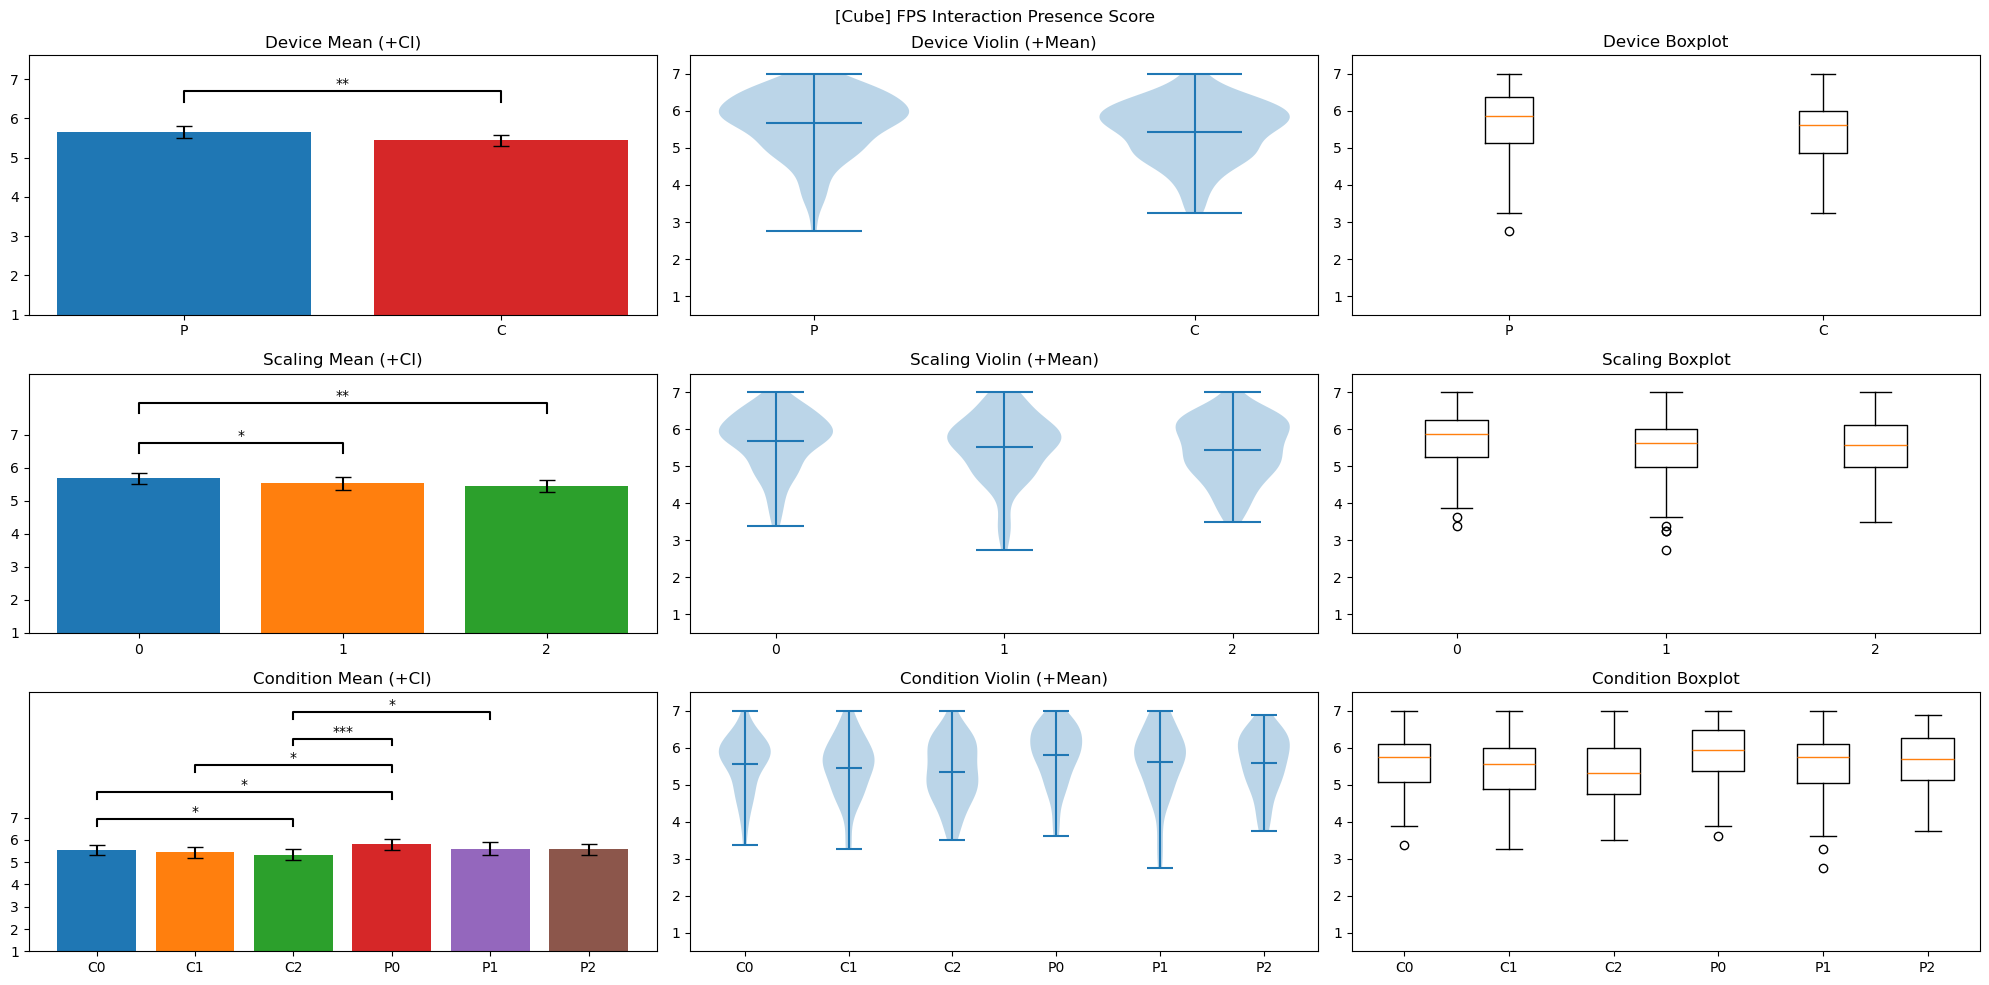

------ [Shovel] FPS Interaction Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,8.580357,1,41,8.580357,13.458924,0.000696,0.000696,0.044863,1.000000,✅
1,Scaling,5.972594,2,82,2.986297,9.577053,0.000183,0.000479,0.031660,0.836687,✅
2,Device * Scaling,0.368676,2,82,0.184338,0.738249,0.481100,0.480730,0.002014,0.997010,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.668641,41.0,two-sided,0.000696,NaN,NaN,41.614,-0.490650,✅
1,Scaling,-,0,1,True,True,2.279956,41.0,two-sided,0.027881,0.055763,holm,1.689,0.250442,🟨
2,Scaling,-,0,2,True,True,4.842182,41.0,two-sided,0.000019,0.000056,holm,1121.736,0.489464,✅
3,Scaling,-,1,2,True,True,2.000481,41.0,two-sided,0.052100,0.055763,holm,1.015,0.258621,🟨


------ [Shovel] FPS Interaction Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,14.921627,5,2.984325,8.47555,2.608471e-07,0.000006,0.075515,0.740785,False,0.438264,0.003739,✅
1,Error,72.182540,205,0.352110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.870572,41.0,two-sided,3.890567e-01,1.000000,holm,0.238,0.129251,❌
1,Condition,C0,C2,True,True,3.792309,41.0,two-sided,4.825176e-04,0.006273,holm,57.77,0.423591,✅
2,Condition,C0,P0,True,True,-2.971344,41.0,two-sided,4.941814e-03,0.044476,holm,7.359,-0.510761,✅
3,Condition,C0,P1,True,True,-1.027437,41.0,two-sided,3.102385e-01,1.000000,holm,0.273,-0.184135,❌
4,Condition,C0,P2,True,True,-0.357804,41.0,two-sided,7.223256e-01,1.000000,holm,0.177,-0.052514,❌
5,Condition,C1,C2,True,True,2.199464,41.0,two-sided,3.354054e-02,0.234784,holm,1.451,0.319694,❌
6,Condition,C1,P0,True,True,-4.320494,41.0,two-sided,9.656676e-05,0.001352,holm,247.983,-0.663679,✅
7,Condition,C1,P1,True,True,-1.838996,41.0,two-sided,7.316589e-02,0.438995,holm,0.775,-0.310283,❌
8,Condition,C1,P2,True,True,-1.050738,41.0,two-sided,2.995330e-01,1.000000,holm,0.279,-0.179191,❌
9,Condition,C2,P0,True,True,-5.868449,41.0,two-sided,6.656451e-07,0.000010,holm,2.47e+04,-0.882032,✅


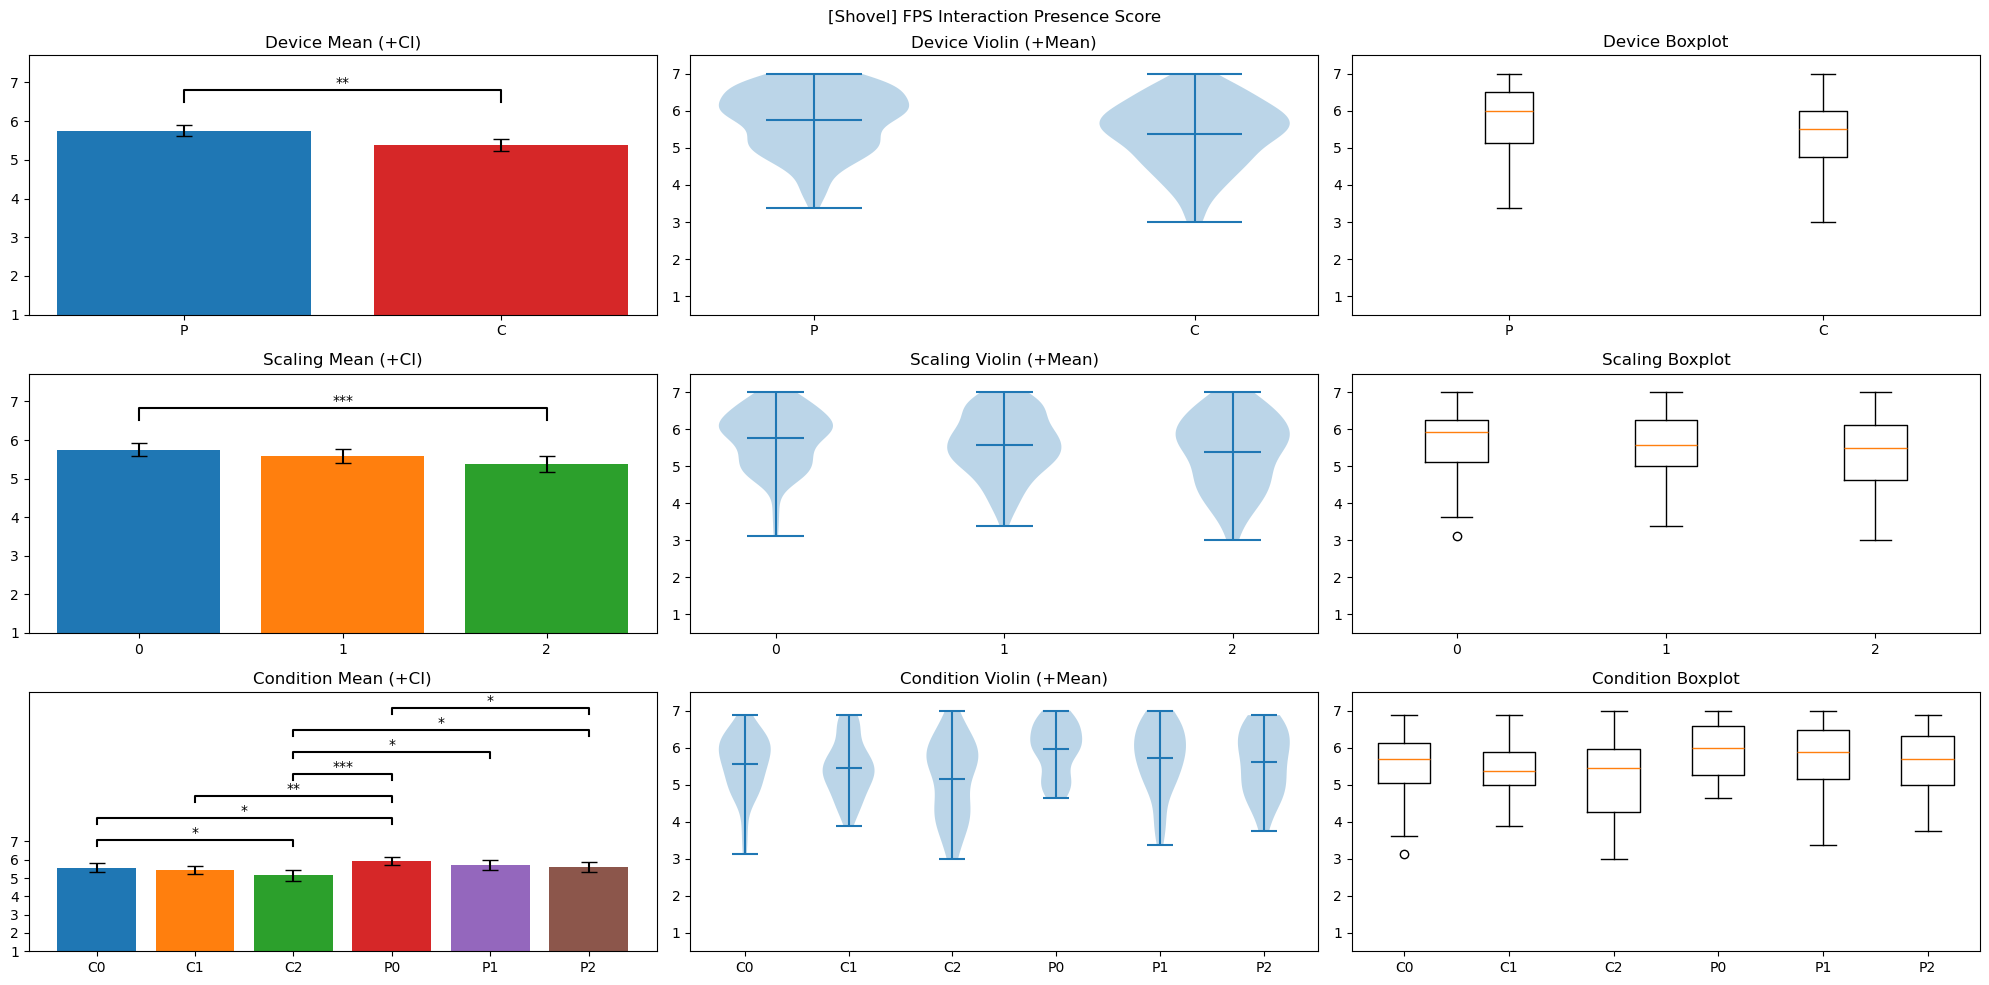

In [508]:
fps_interaction = 'fps_interaction'
#Interaction Presence Score: (FPS-1 + FPS-2 + FPS-4 + FPS-5 + FPS-6 + FPS-7 + FPS-8 + FPS-9) / 8
data[fps_interaction] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9]) / 8,
    axis = 1)

title = 'FPS Interaction Presence Score'
score = fps_interaction
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Scenario Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.682540,1,41,2.682540,4.395644,0.042243,0.042243,0.007872,1.000000,✅
1,Scaling,1.006173,2,82,0.503086,2.167694,0.120955,0.126884,0.002967,0.896207,❌
2,Device * Scaling,0.050265,2,82,0.025132,0.183251,0.832899,0.789457,0.000149,0.819015,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.096579,41.0,two-sided,0.042243,NaN,NaN,1.202,-0.182775,✅


------ [Cube] FPS Scenario Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,3.738977,5,0.747795,2.772214,0.019041,0.045701,0.010938,0.586456,False,0.193219,2.182182e-08,✅
1,Error,55.298060,205,0.269747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,1.207002,41.0,two-sided,0.234349,1.000000,holm,0.328,0.098152,❌
1,Condition,C0,C2,True,True,1.088826,41.0,two-sided,0.282589,1.000000,holm,0.29,0.084644,❌
2,Condition,C0,P0,True,True,-2.334611,41.0,two-sided,0.024541,0.368119,holm,1.878,-0.214460,❌
3,Condition,C0,P1,True,True,-0.728304,41.0,two-sided,0.470567,1.000000,holm,0.214,-0.060326,❌
4,Condition,C0,P2,True,True,-0.907811,41.0,two-sided,0.369283,1.000000,holm,0.245,-0.082586,❌
5,Condition,C1,C2,True,True,-0.157253,41.0,two-sided,0.875817,1.000000,holm,0.169,-0.013663,❌
6,Condition,C1,P0,True,True,-2.232039,41.0,two-sided,0.031138,0.407531,holm,1.542,-0.301858,❌
7,Condition,C1,P1,True,True,-1.392272,41.0,two-sided,0.171346,1.000000,holm,0.408,-0.149760,❌
8,Condition,C1,P2,True,True,-1.569461,41.0,two-sided,0.124227,1.000000,holm,0.517,-0.173555,❌
9,Condition,C2,P0,True,True,-2.261325,41.0,two-sided,0.029109,0.407531,holm,1.63,-0.290053,❌


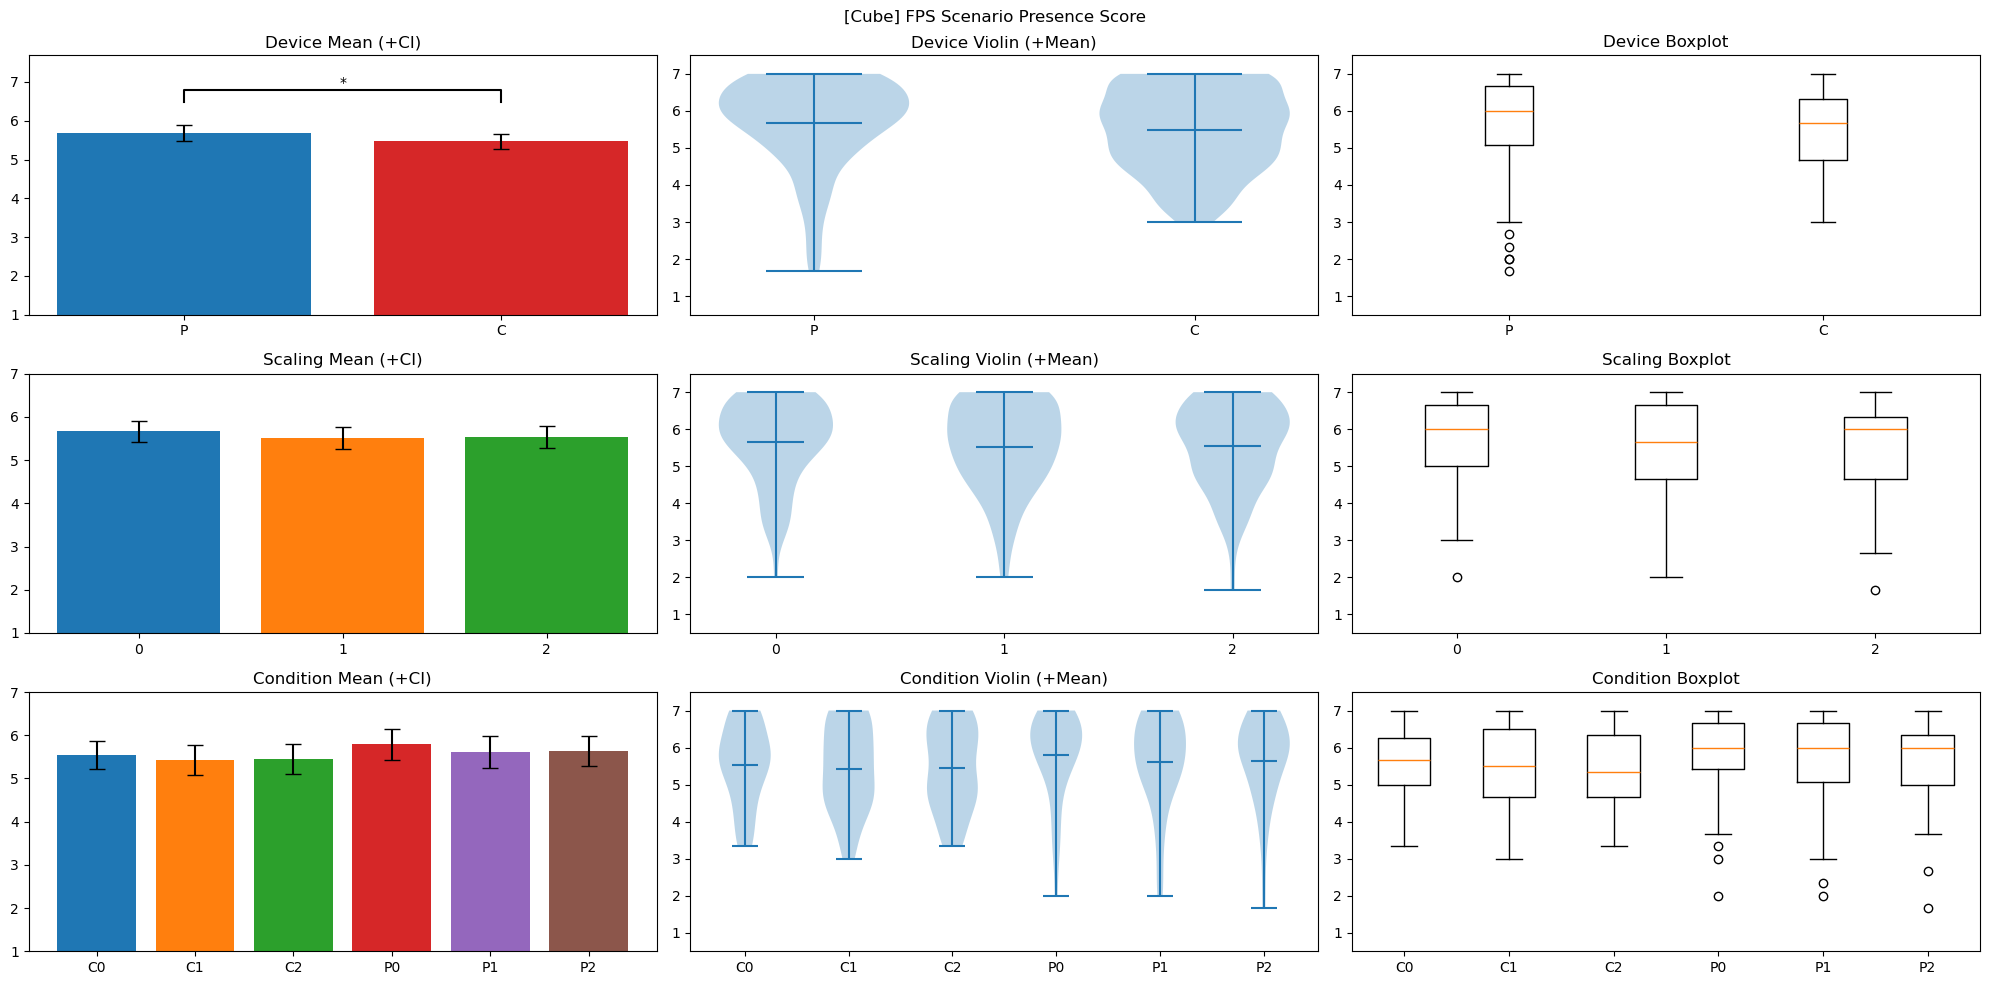

------ [Shovel] FPS Scenario Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.432540,1,41,5.432540,7.956670,0.007351,0.007351,0.021698,1.000000,✅
1,Scaling,1.597884,2,82,0.798942,3.288712,0.042279,0.047499,0.006481,0.904702,✅
2,Device * Scaling,0.137566,2,82,0.068783,0.337449,0.714575,0.695876,0.000561,0.916398,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.820757,41.0,two-sided,0.007351,NaN,NaN,5.218,-0.316189,✅
1,Scaling,-,0,1,True,True,0.507601,41.0,two-sided,0.614453,0.614453,holm,0.188,0.037078,❌
2,Scaling,-,0,2,True,True,2.208195,41.0,two-sided,0.032881,0.098643,holm,1.475,0.191918,🟨
3,Scaling,-,1,2,True,True,1.855072,41.0,two-sided,0.070786,0.141572,holm,0.796,0.163603,❌


------ [Shovel] FPS Scenario Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,7.167989,5,1.433598,4.547351,0.000592,0.004336,0.028432,0.613777,False,0.210638,8.585486e-08,✅
1,Error,64.628307,205,0.315260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.232317,41.0,two-sided,0.817448,1.000000,holm,0.171,-0.023994,❌
1,Condition,C0,C2,True,True,1.512346,41.0,two-sided,0.138116,0.828699,holm,0.478,0.129628,❌
2,Condition,C0,P0,True,True,-2.437235,41.0,two-sided,0.019226,0.230710,holm,2.302,-0.353998,❌
3,Condition,C0,P1,True,True,-1.662122,41.0,two-sided,0.104117,0.795607,holm,0.59,-0.262523,❌
4,Condition,C0,P2,True,True,-0.941719,41.0,two-sided,0.351852,1.000000,holm,0.252,-0.126865,❌
5,Condition,C1,C2,True,True,1.890136,41.0,two-sided,0.065823,0.658231,holm,0.843,0.165167,❌
6,Condition,C1,P0,True,True,-3.093003,41.0,two-sided,0.003559,0.049598,holm,9.799,-0.367755,✅
7,Condition,C1,P1,True,True,-1.884643,41.0,two-sided,0.066580,0.658231,holm,0.835,-0.265266,❌
8,Condition,C1,P2,True,True,-0.833616,41.0,two-sided,0.409328,1.000000,holm,0.231,-0.114924,❌
9,Condition,C2,P0,True,True,-4.030544,41.0,two-sided,0.000236,0.003534,holm,110.295,-0.487632,✅


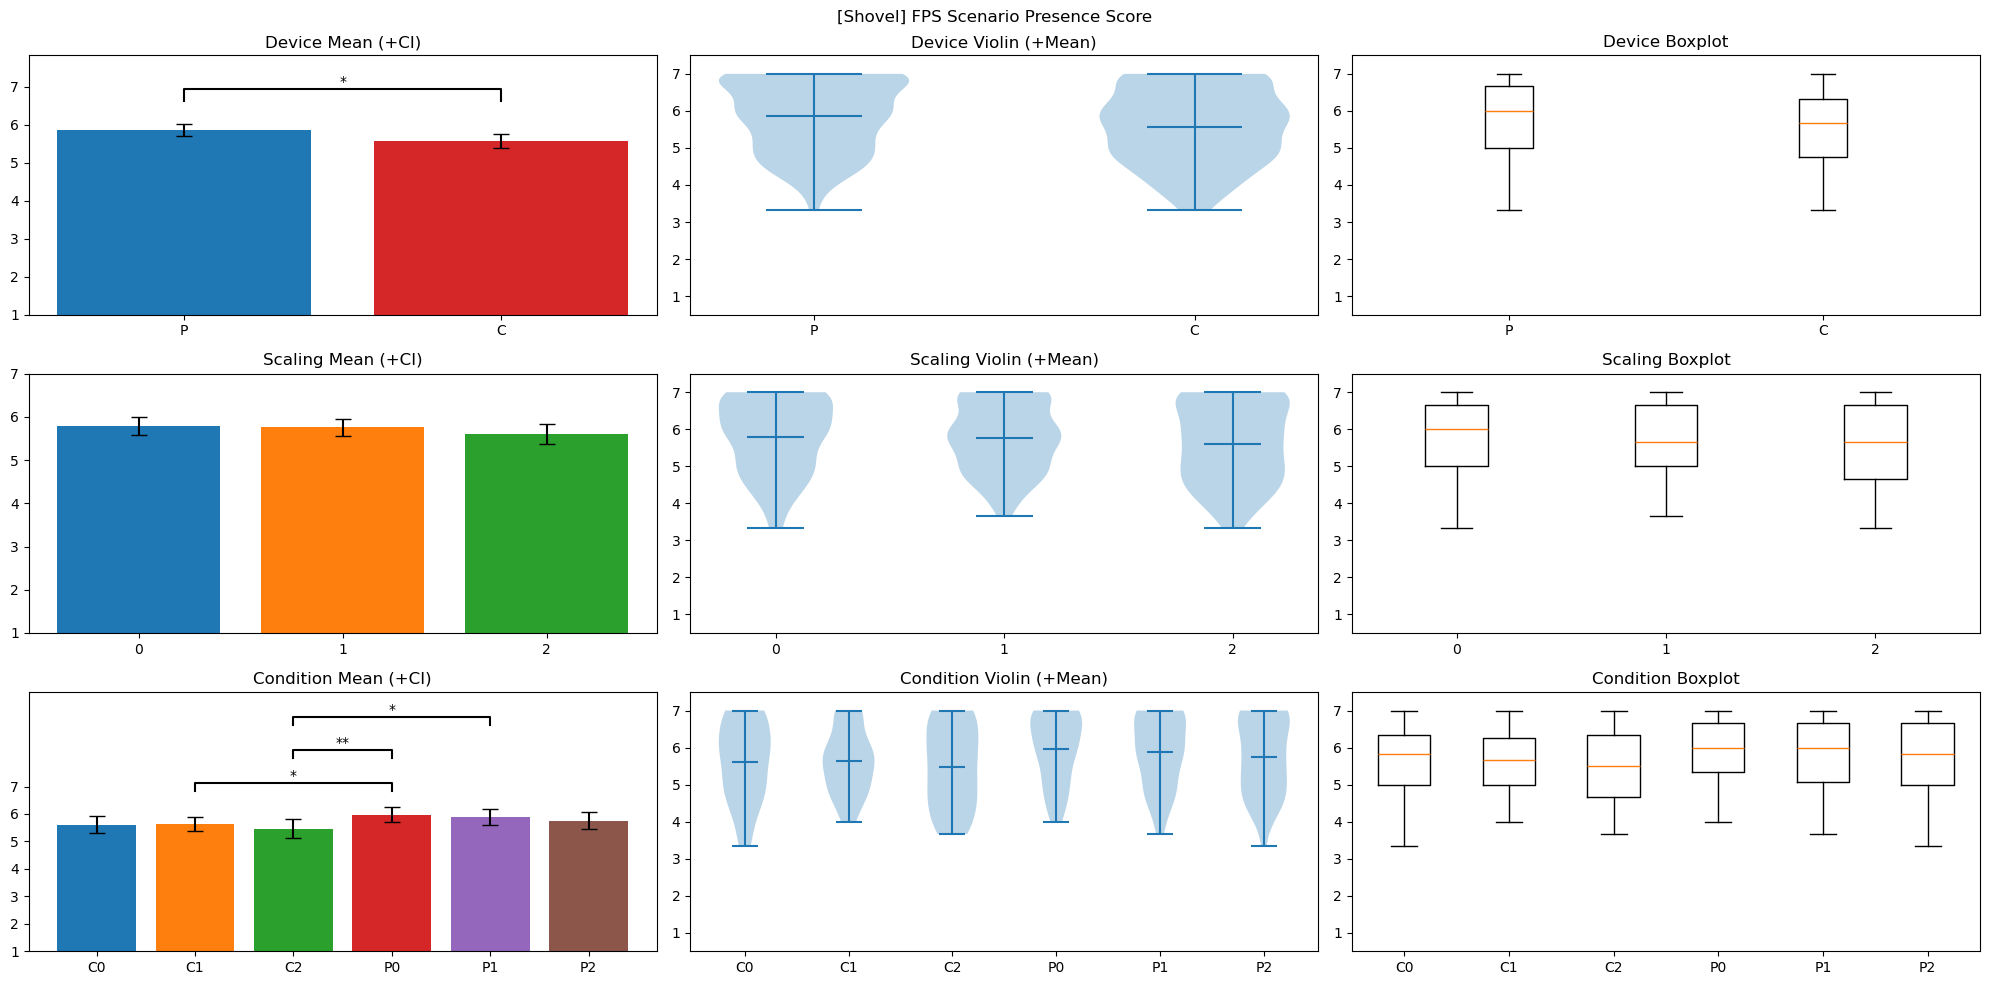

In [509]:
fps_scenario = 'fps_scenario'
#Scenario Presence Score: (FPS-3 + FPS-4 + FPS-8) / 3
data[fps_scenario] = data.apply(lambda x: 
    (x[fps_3] + x[fps_4] + x[fps_8]) / 3,
    axis = 1)

title = 'FPS Scenario Presence Score'
score = fps_scenario
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Display Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,4.587302,1,41,4.587302,12.982157,0.000843,0.000843,0.018135,1.000000,✅
1,Scaling,0.952543,2,82,0.476271,3.066800,0.051948,0.056541,0.003821,0.920506,🟨
2,Device * Scaling,0.255750,2,82,0.127875,0.900140,0.410491,0.401181,0.001029,0.896042,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.603076,41.0,two-sided,0.000843,NaN,NaN,35.051,-0.280199,✅


------ [Cube] FPS Display Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,5.795594,5,1.159119,6.113013,0.000027,0.000276,0.022803,0.70714,False,0.329034,0.000074,✅
1,Error,38.871072,205,0.189615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.520424,41.0,two-sided,0.605567,1.000000,holm,0.189,0.037885,❌
1,Condition,C0,C2,True,True,1.536135,41.0,two-sided,0.132187,0.582215,holm,0.493,0.138488,❌
2,Condition,C0,P0,True,True,-4.061363,41.0,two-sided,0.000214,0.003217,holm,120.077,-0.332201,✅
3,Condition,C0,P1,True,True,-1.943275,41.0,two-sided,0.058870,0.470959,holm,0.92,-0.136264,❌
4,Condition,C0,P2,True,True,-1.999415,41.0,two-sided,0.052220,0.469981,holm,1.013,-0.170364,❌
5,Condition,C1,C2,True,True,1.020078,41.0,two-sided,0.313673,0.941020,holm,0.271,0.099039,❌
6,Condition,C1,P0,True,True,-3.035378,41.0,two-sided,0.004161,0.054093,holm,8.548,-0.365527,🟨
7,Condition,C1,P1,True,True,-1.603763,41.0,two-sided,0.116443,0.582215,holm,0.542,-0.169894,❌
8,Condition,C1,P2,True,True,-1.888587,41.0,two-sided,0.066036,0.470959,holm,0.84,-0.205105,❌
9,Condition,C2,P0,True,True,-3.826486,41.0,two-sided,0.000436,0.006101,holm,63.313,-0.467979,✅


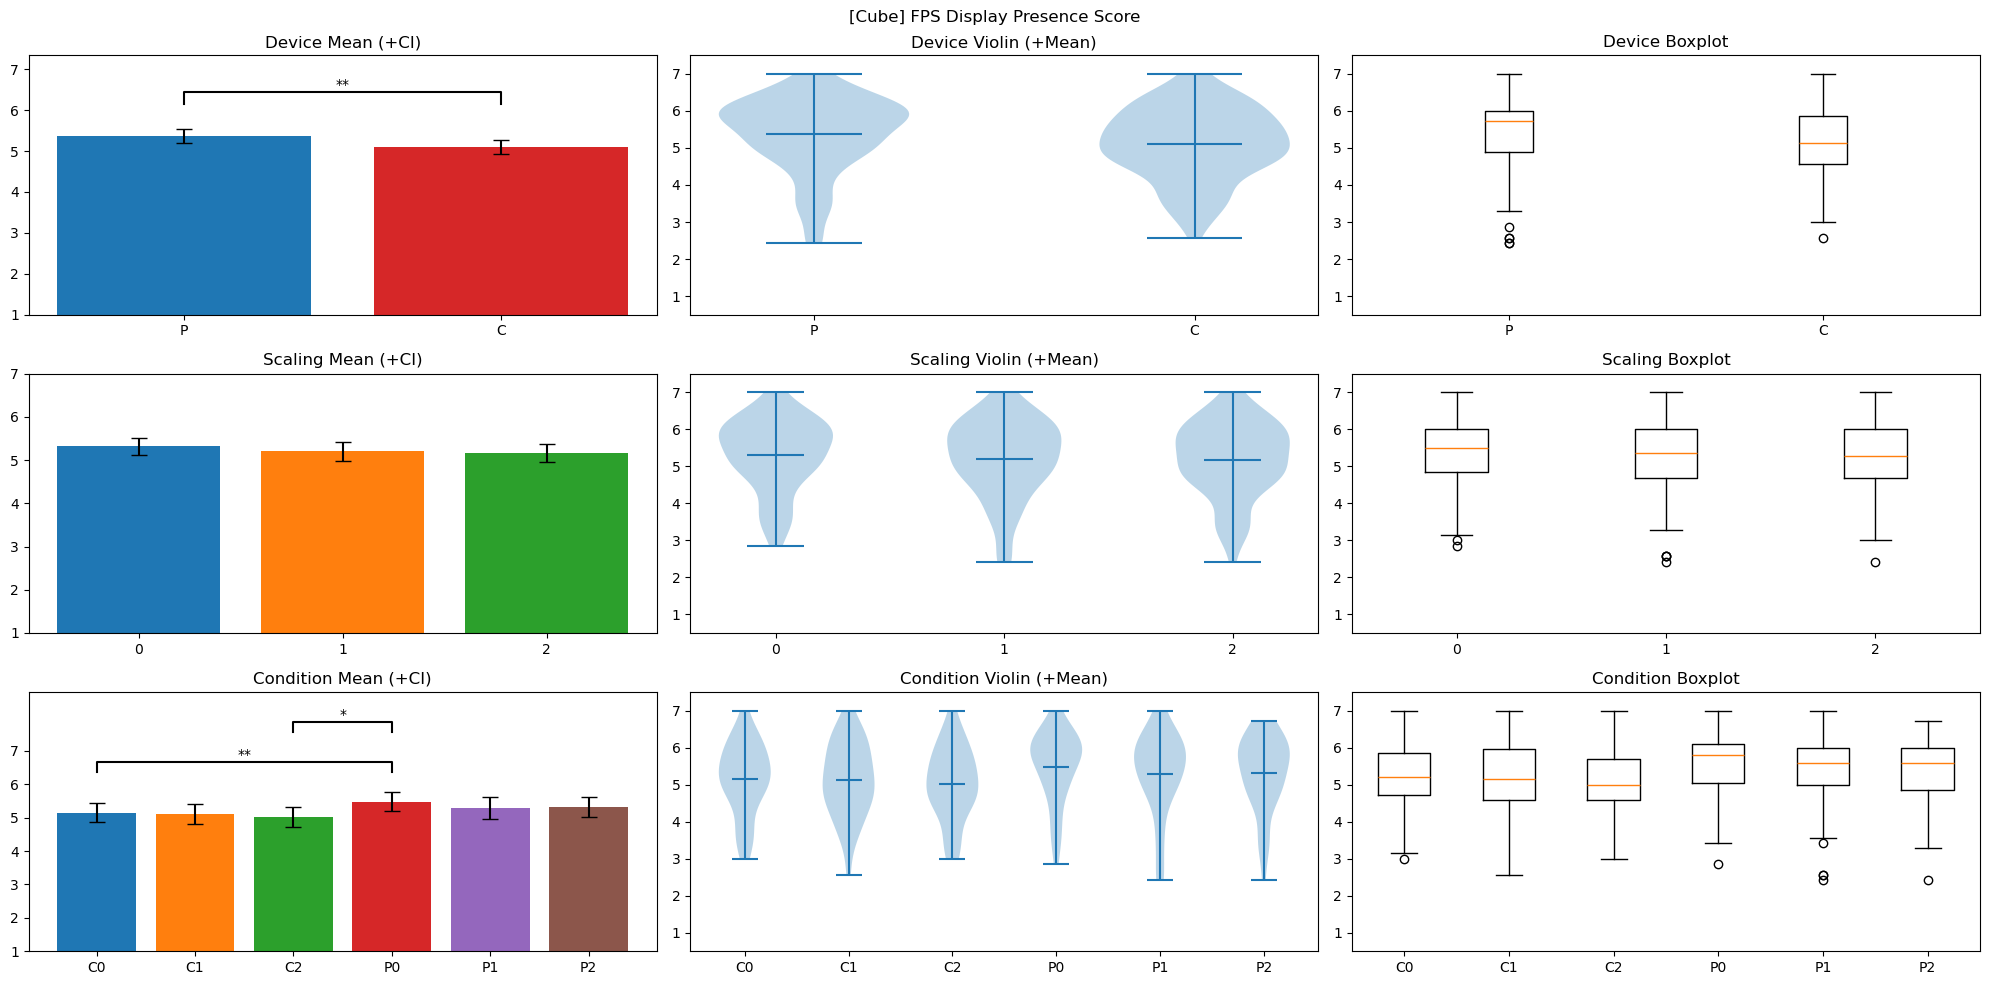

------ [Shovel] FPS Display Presence Score: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.773324,1,41,5.773324,9.517922,0.003636,0.003636,0.027364,1.000000,✅
1,Scaling,2.429057,2,82,1.214529,6.245894,0.002987,0.004845,0.011698,0.857978,✅
2,Device * Scaling,0.275510,2,82,0.137755,0.780127,0.461719,0.460377,0.001341,0.988165,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.085113,41.0,two-sided,0.003636,NaN,NaN,9.616,-0.355841,✅
1,Scaling,-,0,1,True,True,1.469643,41.0,two-sided,0.149291,0.149291,holm,0.451,0.102868,❌
2,Scaling,-,0,2,True,True,3.443105,41.0,two-sided,0.001338,0.004013,holm,23.221,0.275082,✅
3,Scaling,-,1,2,True,True,1.984281,41.0,two-sided,0.053945,0.107891,holm,0.987,0.184645,❌


------ [Shovel] FPS Display Presence Score: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,8.477891,5,1.695578,6.286255,0.000019,0.000319,0.039674,0.659824,False,0.330722,0.00008,✅
1,Error,55.294218,205,0.269728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.039148,41.0,two-sided,0.968963,1.000000,holm,0.167,0.003952,❌
1,Condition,C0,C2,True,True,2.656585,41.0,two-sided,0.011196,0.123155,holm,3.638,0.221198,❌
2,Condition,C0,P0,True,True,-2.996886,41.0,two-sided,0.004615,0.055382,holm,7.81,-0.411566,🟨
3,Condition,C0,P1,True,True,-1.601413,41.0,two-sided,0.116963,0.584817,holm,0.541,-0.232010,❌
4,Condition,C0,P2,True,True,-0.923285,41.0,two-sided,0.361261,1.000000,holm,0.248,-0.123393,❌
5,Condition,C1,C2,True,True,2.153147,41.0,two-sided,0.037240,0.297920,holm,1.332,0.224550,❌
6,Condition,C1,P0,True,True,-3.580261,41.0,two-sided,0.000901,0.012608,holm,33.031,-0.432089,✅
7,Condition,C1,P1,True,True,-1.739261,41.0,two-sided,0.089493,0.536957,holm,0.663,-0.245057,❌
8,Condition,C1,P2,True,True,-0.925848,41.0,two-sided,0.359943,1.000000,holm,0.249,-0.131940,❌
9,Condition,C2,P0,True,True,-4.578584,41.0,two-sided,0.000043,0.000645,holm,519.433,-0.590643,✅


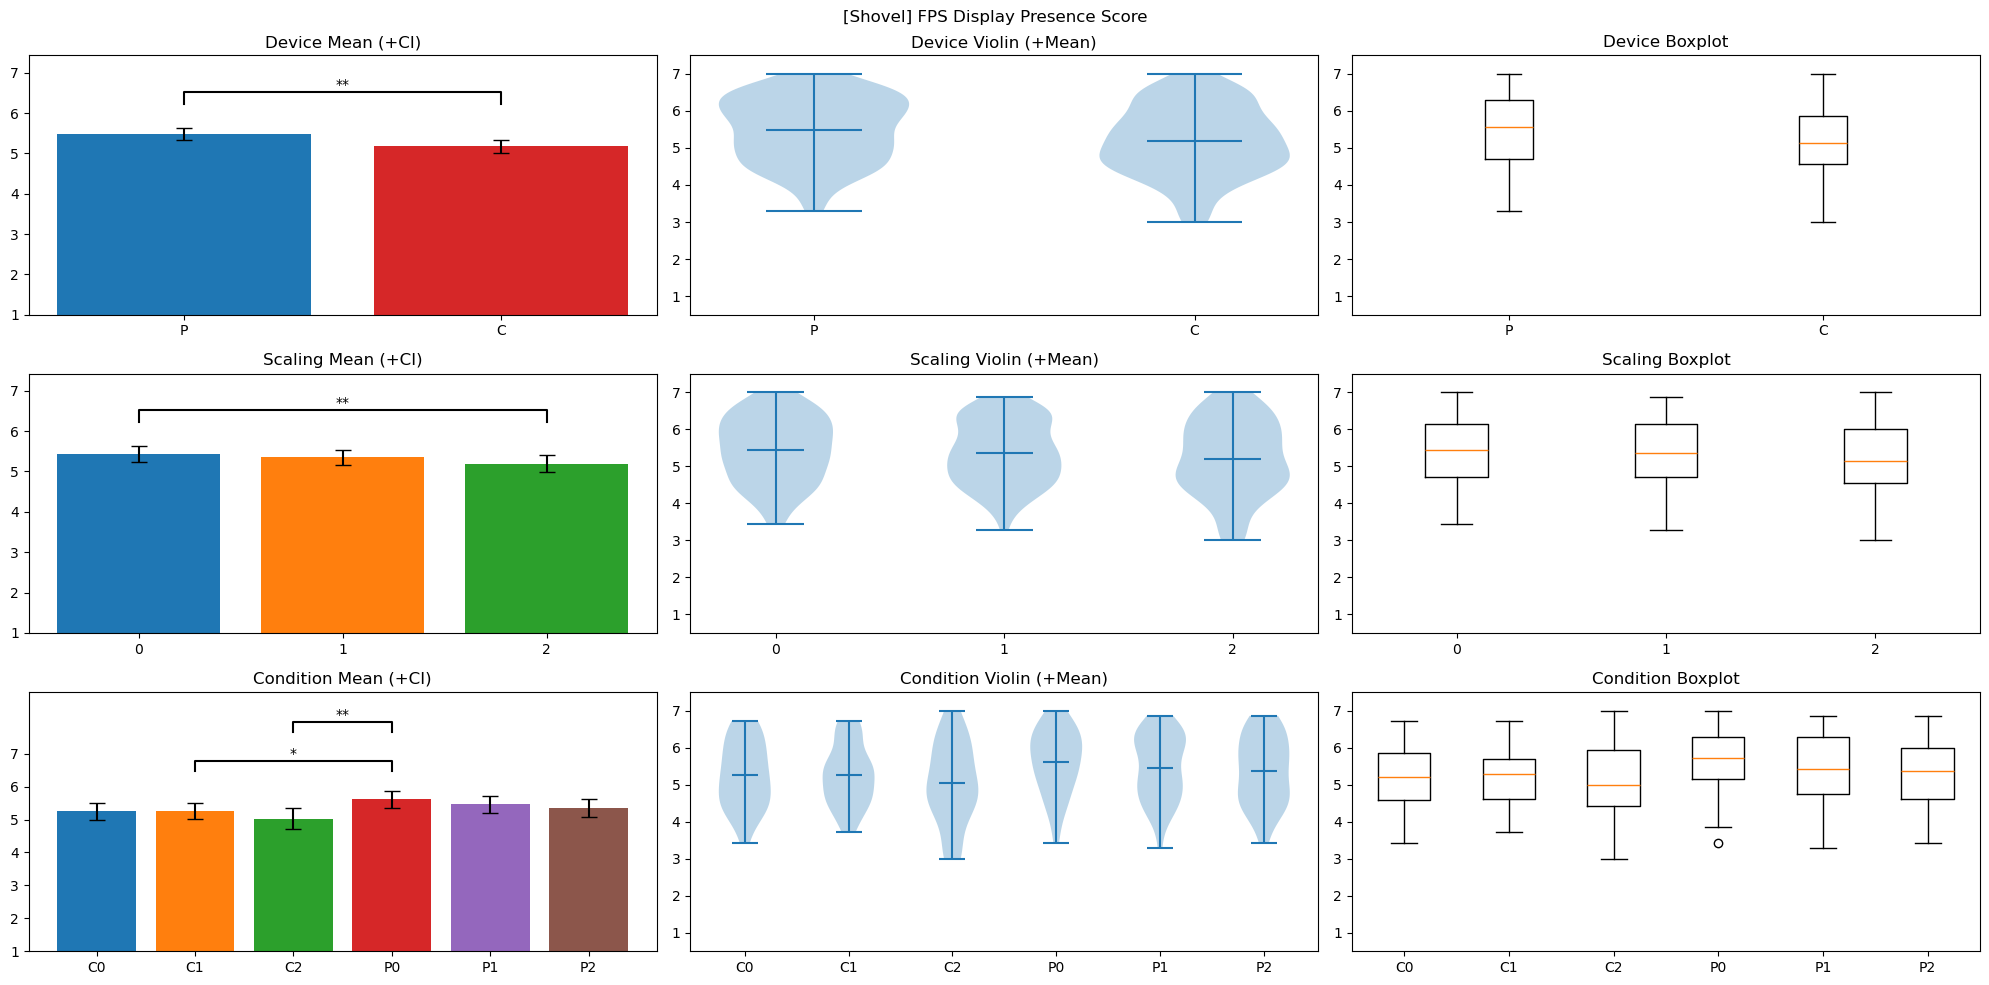

In [510]:
fps_display = 'fps_display'
#Display Presence Score: (FPS-1 + FPS-2 + FPS-3 + FPS-4 +FPS-7 +FPS-8 + FPS-10) / 7
data[fps_display] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_7] + x[fps_8] + x[fps_10]) / 7,
    axis = 1)

title = 'FPS Display Presence Score'
score = fps_display
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Borg Challenge Rating (CR10): Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,4.063492,1,41,4.063492,18.642984,0.000097,0.000097,0.027312,1.000000,✅
1,Scaling,0.341270,2,82,0.170635,0.933298,0.397391,0.391804,0.002353,0.930110,❌
2,Device * Scaling,0.293651,2,82,0.146825,0.878402,0.419319,0.408023,0.002025,0.881868,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.317752,41.0,two-sided,0.000097,NaN,NaN,246.064,-0.366425,✅


------ [Cube] Borg Challenge Rating (CR10): One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,ng2,eps,Significance
0,Condition,4.698413,5,0.939683,5.118515,0.000191,0.031446,0.872757,✅
1,Error,37.634921,205,0.183585,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.000000,41.0,two-sided,1.000000,1.000000,holm,0.167,0.000000,❌
1,Condition,C0,C2,True,True,-0.239799,41.0,two-sided,0.811681,1.000000,holm,0.171,-0.031854,❌
2,Condition,C0,P0,True,True,-2.010536,41.0,two-sided,0.050983,0.407864,holm,1.033,-0.220883,❌
3,Condition,C0,P1,True,True,-3.532458,41.0,two-sided,0.001035,0.014483,holm,29.189,-0.417430,✅
4,Condition,C0,P2,True,True,-2.912518,41.0,two-sided,0.005778,0.069340,holm,6.425,-0.367829,🟨
5,Condition,C1,C2,True,True,-0.239799,41.0,two-sided,0.811681,1.000000,holm,0.171,-0.031169,❌
6,Condition,C1,P0,True,True,-1.738118,41.0,two-sided,0.089696,0.627874,holm,0.662,-0.216216,❌
7,Condition,C1,P1,True,True,-3.322418,41.0,two-sided,0.001885,0.024499,holm,17.14,-0.409528,✅
8,Condition,C1,P2,True,True,-2.614065,41.0,two-sided,0.012457,0.124575,holm,3.322,-0.360482,❌
9,Condition,C2,P0,True,True,-1.635210,41.0,two-sided,0.109661,0.657963,holm,0.567,-0.195901,❌


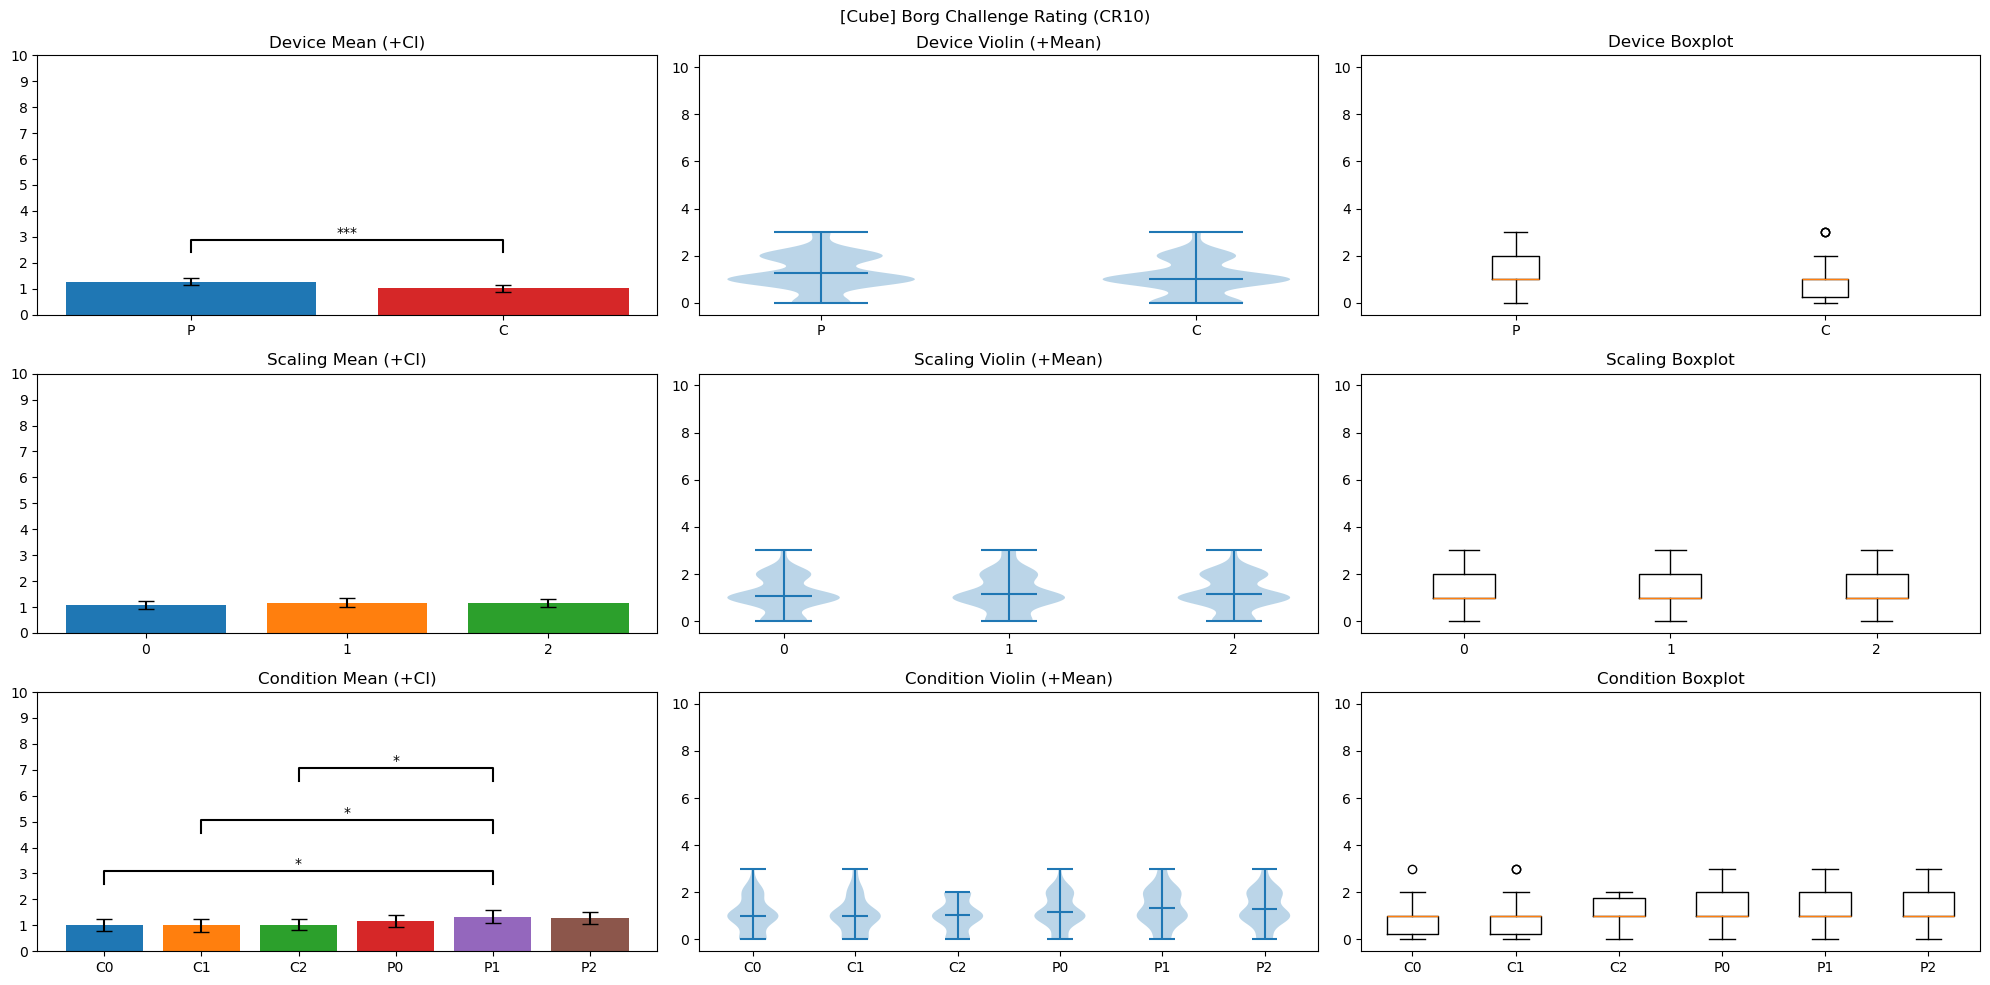

------ [Shovel] Borg Challenge Rating (CR10): Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,7.337302,1,41,7.337302,26.949520,0.000006,0.000006,0.028797,1.000000,✅
1,Scaling,0.722222,2,82,0.361111,1.460274,0.238146,0.239129,0.002910,0.899140,❌
2,Device * Scaling,0.150794,2,82,0.075397,0.481161,0.619799,0.603025,0.000609,0.914342,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-5.191293,41.0,two-sided,0.000006,NaN,NaN,3167.411,-0.362265,✅


------ [Shovel] Borg Challenge Rating (CR10): One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,8.210317,5,1.642063,7.600484,0.000001,0.000012,0.032114,0.802925,False,0.445405,0.004594,✅
1,Error,44.289683,205,0.216047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.159423,41.0,two-sided,0.252992,1.000000,holm,0.312,-0.096991,❌
1,Condition,C0,C2,True,True,-1.536135,41.0,two-sided,0.132187,0.793123,holm,0.493,-0.187320,❌
2,Condition,C0,P0,True,True,-4.183565,41.0,two-sided,0.000148,0.002065,holm,168.648,-0.414957,✅
3,Condition,C0,P1,True,True,-3.948614,41.0,two-sided,0.000302,0.003926,holm,88.119,-0.438345,✅
4,Condition,C0,P2,True,True,-4.597175,41.0,two-sided,0.000041,0.000608,holm,548.168,-0.446599,✅
5,Condition,C1,C2,True,True,-1.070912,41.0,two-sided,0.290473,1.000000,holm,0.285,-0.094584,❌
6,Condition,C1,P0,True,True,-2.804448,41.0,two-sided,0.007669,0.069025,holm,5.031,-0.320728,🟨
7,Condition,C1,P1,True,True,-3.322418,41.0,two-sided,0.001885,0.020730,holm,17.14,-0.344579,✅
8,Condition,C1,P2,True,True,-3.543307,41.0,two-sided,0.001003,0.012031,holm,30.017,-0.360482,✅
9,Condition,C2,P0,True,True,-1.851282,41.0,two-sided,0.071341,0.499388,holm,0.791,-0.214162,❌


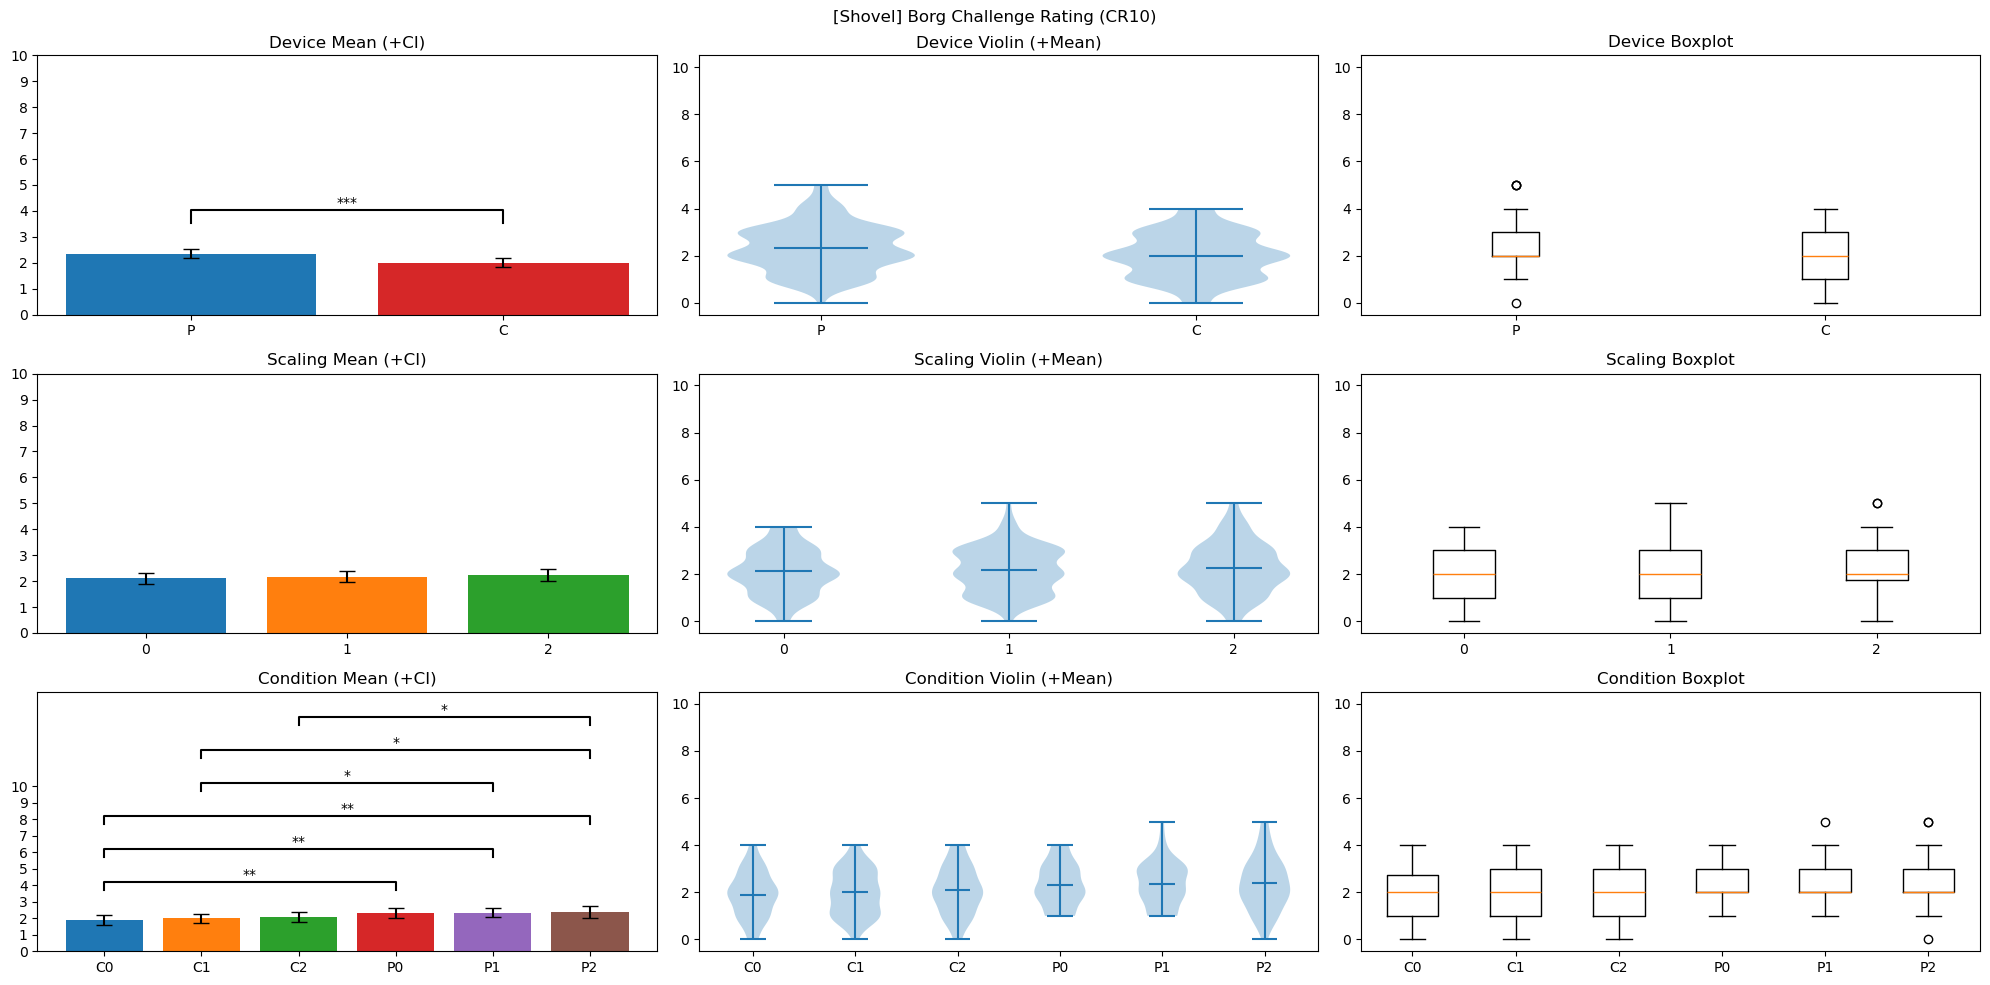

In [511]:
borg_cr_numeric = 'borg_cr_numeric'
#Format: X(X) - ...
data[borg_cr_numeric] = data.apply(lambda x: int(x[borg_cr].split()[0]), axis = 1)

title = 'Borg Challenge Rating (CR10)'
score = borg_cr_numeric
scale = [0,10]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Samn-Perelli Fatigue Level: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.146825,1,41,1.146825,8.783543,0.005044,0.005044,0.007598,1.000000,✅
1,Scaling,0.293651,2,82,0.146825,0.878402,0.419319,0.386302,0.001957,0.697315,❌
2,Device * Scaling,0.341270,2,82,0.170635,1.448644,0.240836,0.241104,0.002273,0.686872,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.963704,41.0,two-sided,0.005044,NaN,NaN,7.23,-0.186481,✅


------ [Cube] Samn-Perelli Fatigue Level: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,1.781746,5,0.356349,2.543734,0.029356,0.061211,0.011755,0.582119,False,0.115316,4.615381e-12,🟨
1,Error,28.718254,205,0.140089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


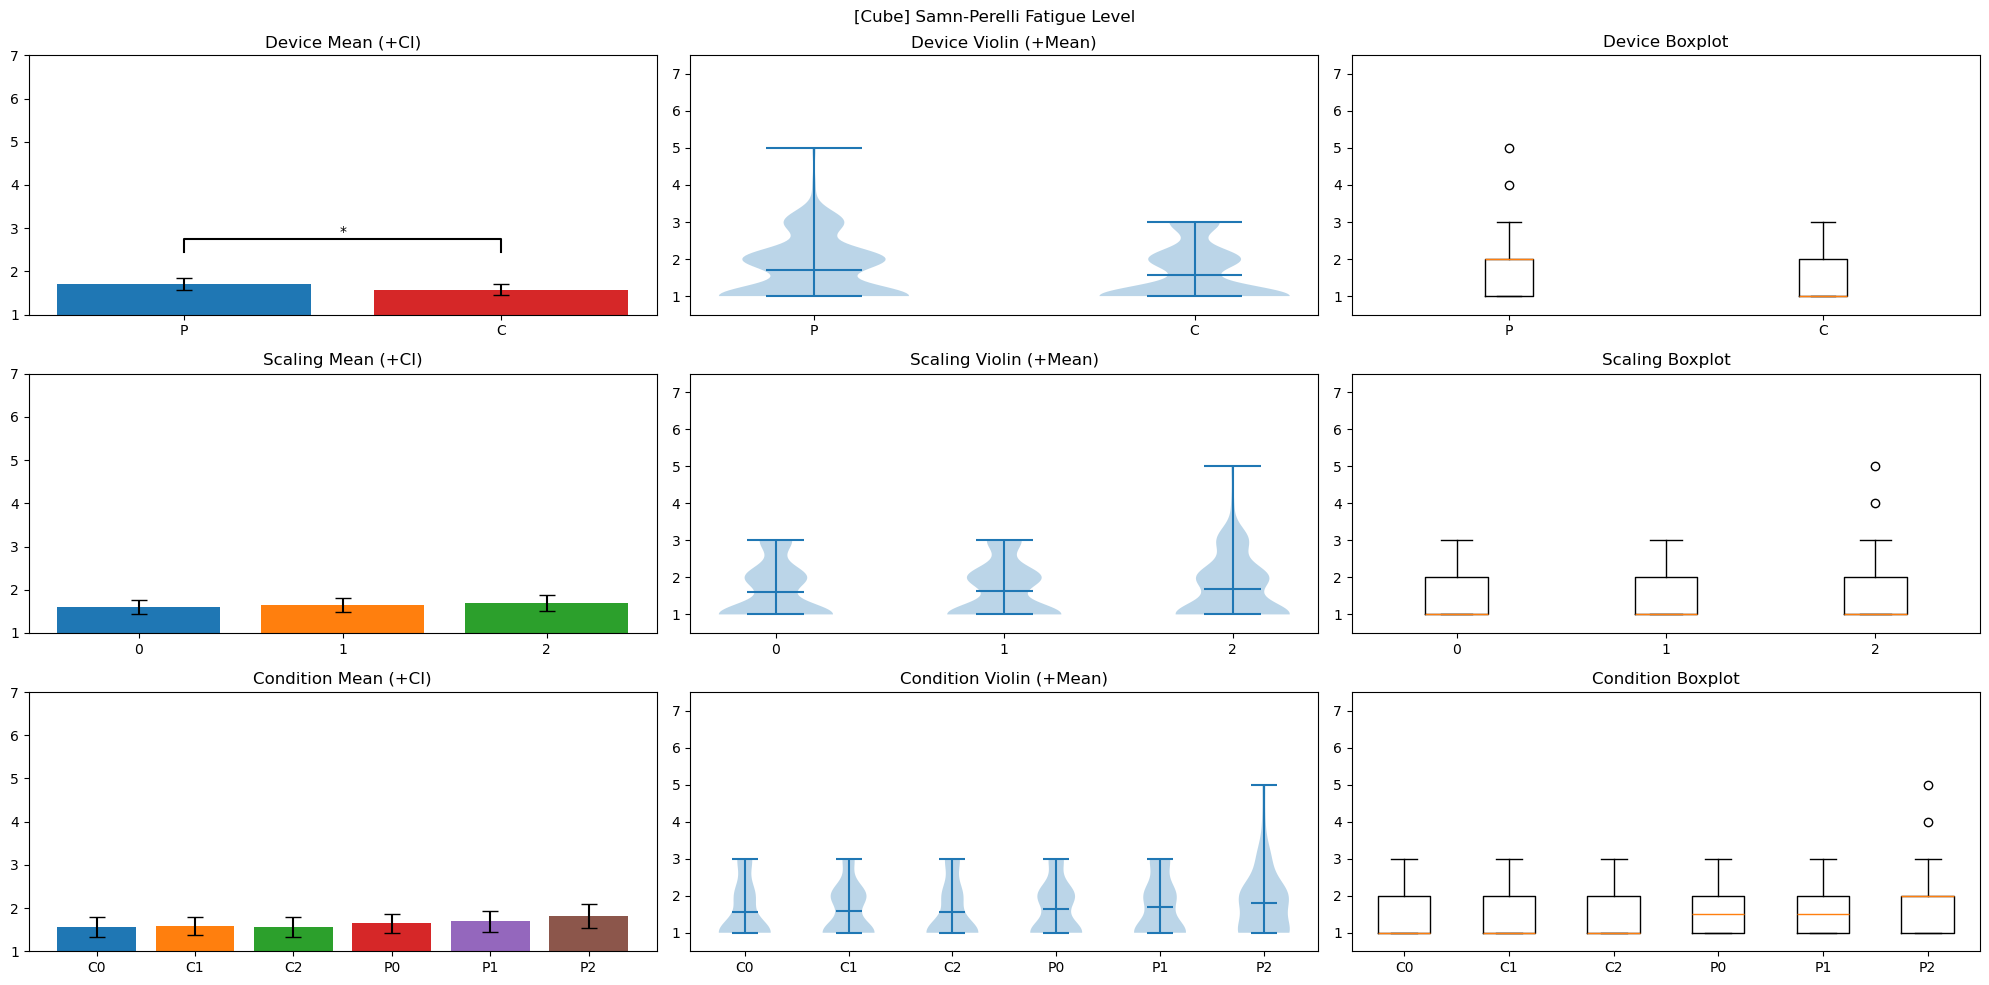

------ [Shovel] Samn-Perelli Fatigue Level: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.892857,1,41,2.892857,9.165593,0.004251,0.004251,0.009330,1.000000,✅
1,Scaling,1.960317,2,82,0.980159,4.221342,0.017991,0.023958,0.006341,0.848962,✅
2,Device * Scaling,0.500000,2,82,0.250000,1.069565,0.347896,0.338439,0.001625,0.830403,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.027473,41.0,two-sided,0.004251,NaN,NaN,8.391,-0.203055,✅
1,Scaling,-,0,1,True,True,-2.553963,41.0,two-sided,0.014464,0.043392,holm,2.926,-0.159560,✅
2,Scaling,-,0,2,True,True,-2.283185,41.0,two-sided,0.027673,0.055346,holm,1.7,-0.190844,🟨
3,Scaling,-,1,2,True,True,-0.534212,41.0,two-sided,0.596080,0.596080,holm,0.191,-0.032587,❌


------ [Shovel] Samn-Perelli Fatigue Level: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,5.353175,5,1.070635,4.291179,0.000983,0.002493,0.017129,0.800663,False,0.480115,0.011642,✅
1,Error,51.146825,205,0.249497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.159423,41.0,two-sided,0.252992,1.000000,holm,0.312,-0.090602,❌
1,Condition,C0,C2,True,True,-2.124951,41.0,two-sided,0.039664,0.396645,holm,1.265,-0.220227,❌
2,Condition,C0,P0,True,True,-1.746758,41.0,two-sided,0.088168,0.793510,holm,0.67,-0.178269,❌
3,Condition,C0,P1,True,True,-3.343923,41.0,two-sided,0.001774,0.026604,holm,18.085,-0.386558,✅
4,Condition,C0,P2,True,True,-3.185673,41.0,two-sided,0.002760,0.038639,holm,12.246,-0.320860,✅
5,Condition,C1,C2,True,True,-1.523402,41.0,two-sided,0.135335,0.947344,holm,0.485,-0.128298,❌
6,Condition,C1,P0,True,True,-0.941534,41.0,two-sided,0.351946,1.000000,holm,0.252,-0.086486,❌
7,Condition,C1,P1,True,True,-2.994787,41.0,two-sided,0.004641,0.060336,holm,7.772,-0.292334,🟨
8,Condition,C1,P2,True,True,-2.707013,41.0,two-sided,0.009853,0.118232,holm,4.058,-0.228833,❌
9,Condition,C2,P0,True,True,0.404162,41.0,two-sided,0.688194,1.000000,holm,0.18,0.042147,❌


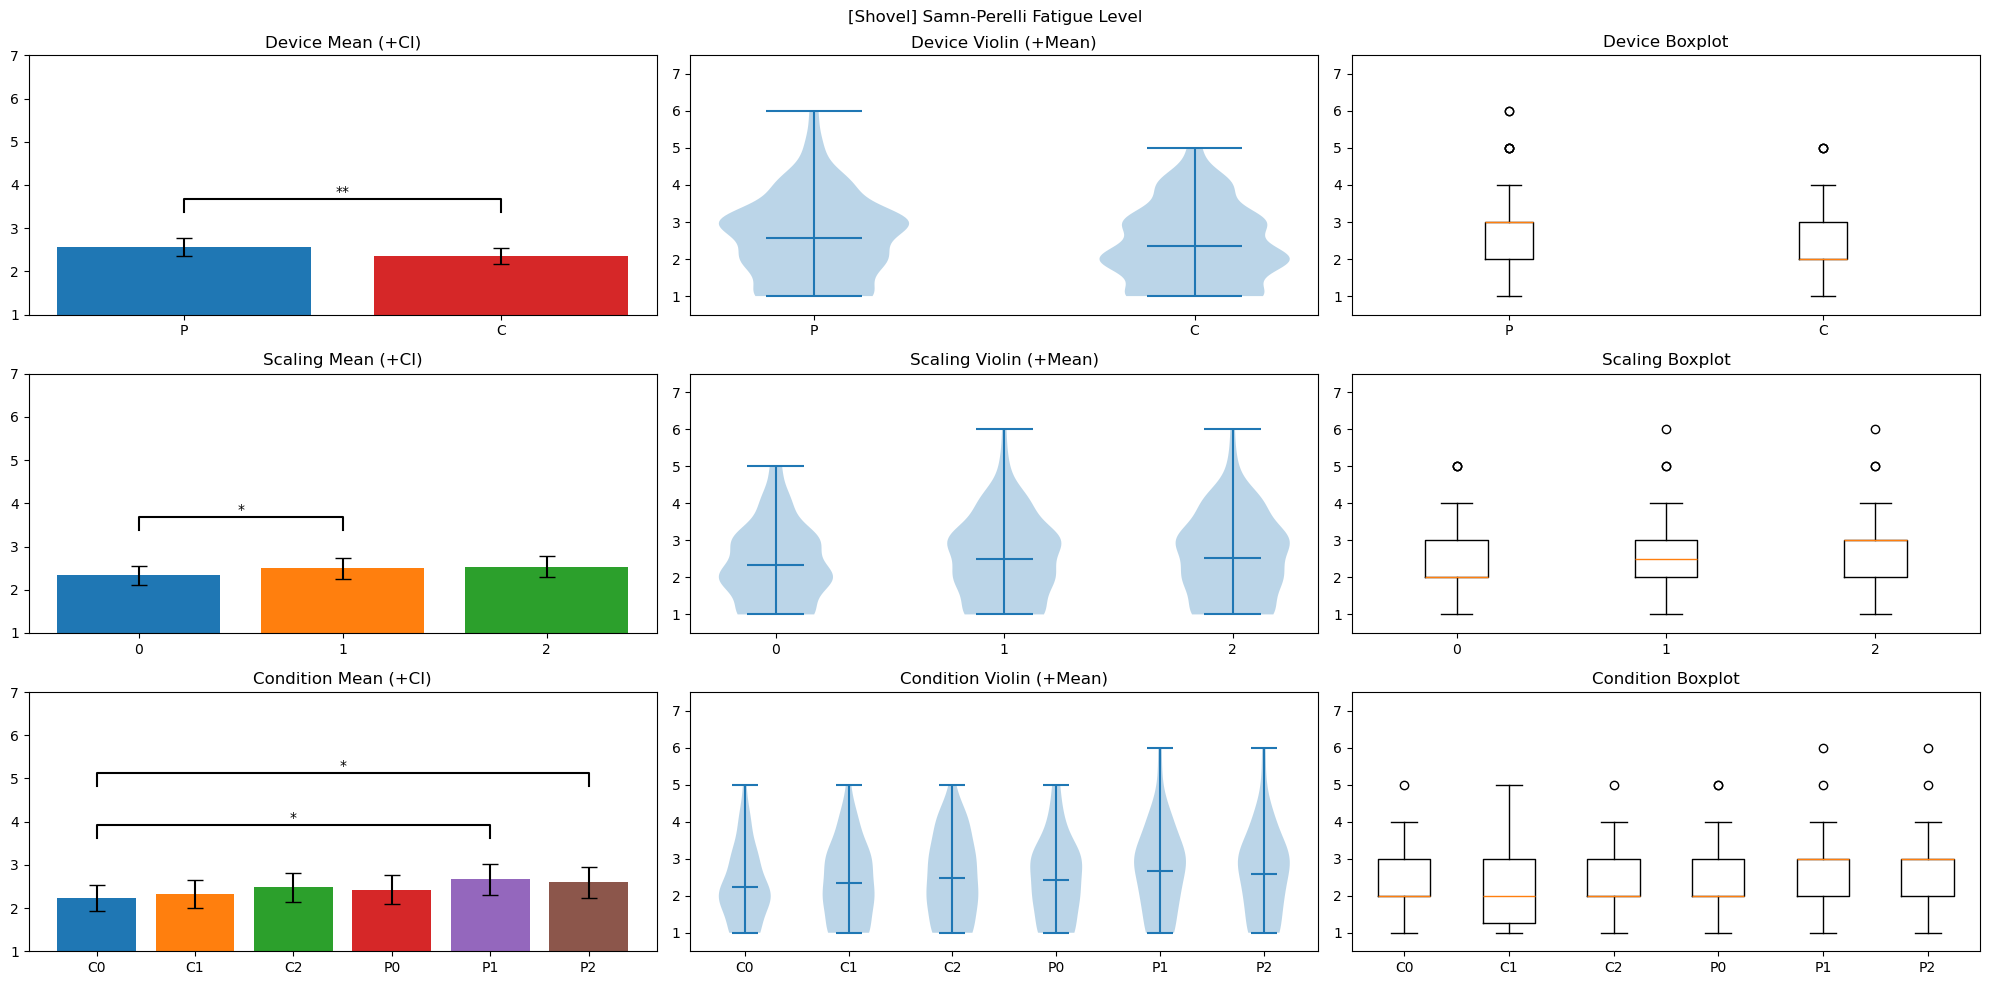

In [512]:
sp_fatigue_numeric = 'sp_fatigue_numeric'
#Format: X - ...
data[sp_fatigue_numeric] = data.apply(lambda x: int(x[sp_fatigue].split()[0]), axis = 1)

title = 'Samn-Perelli Fatigue Level'
score = sp_fatigue_numeric
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Perceived Weight: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,761.285714,1,41,761.285714,178.650041,1.556154e-16,1.556154e-16,0.599438,1.000000,✅
1,Scaling,0.000000,2,82,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.965876,❌
2,Device * Scaling,0.857143,2,82,0.428571,0.584323,5.597873e-01,5.290503e-01,0.001682,0.827061,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-13.366003,41.0,two-sided,1.556154e-16,NaN,NaN,3.837e+13,-2.739345,✅


------ [Cube] Perceived Weight: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,762.142857,5,152.428571,106.0962,6.623942e-55,6.933218e-28,0.599708,0.484018,False,0.075575,3.534629e-15,✅
1,Error,294.523810,205,1.436702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,0.712927,41.0,two-sided,4.799293e-01,1.000000e+00,holm,0.212,0.087658,❌
1,Condition,C0,C2,True,True,0.289559,41.0,two-sided,7.736127e-01,1.000000e+00,holm,0.174,0.043749,❌
2,Condition,C0,P0,True,True,-10.052678,41.0,two-sided,1.257377e-12,8.801637e-12,holm,6.665e+09,-2.219230,✅
3,Condition,C0,P1,True,True,-11.606182,41.0,two-sided,1.554712e-14,1.710183e-13,holm,4.533e+11,-2.457710,✅
4,Condition,C0,P2,True,True,-12.199951,41.0,two-sided,3.148982e-15,3.778778e-14,holm,2.11e+12,-2.514924,✅
5,Condition,C1,C2,True,True,-0.333937,41.0,two-sided,7.401290e-01,1.000000e+00,holm,0.176,-0.042873,❌
6,Condition,C1,P0,True,True,-11.247827,41.0,two-sided,4.165645e-14,4.165645e-13,holm,1.756e+11,-2.259891,✅
7,Condition,C1,P1,True,True,-12.348659,41.0,two-sided,2.125840e-15,2.763592e-14,holm,3.081e+12,-2.491126,✅
8,Condition,C1,P2,True,True,-12.793865,41.0,two-sided,6.665573e-16,9.998359e-15,holm,9.426e+12,-2.545166,✅
9,Condition,C2,P0,True,True,-10.832454,41.0,two-sided,1.333071e-13,1.066457e-12,holm,5.742e+10,-2.208903,✅


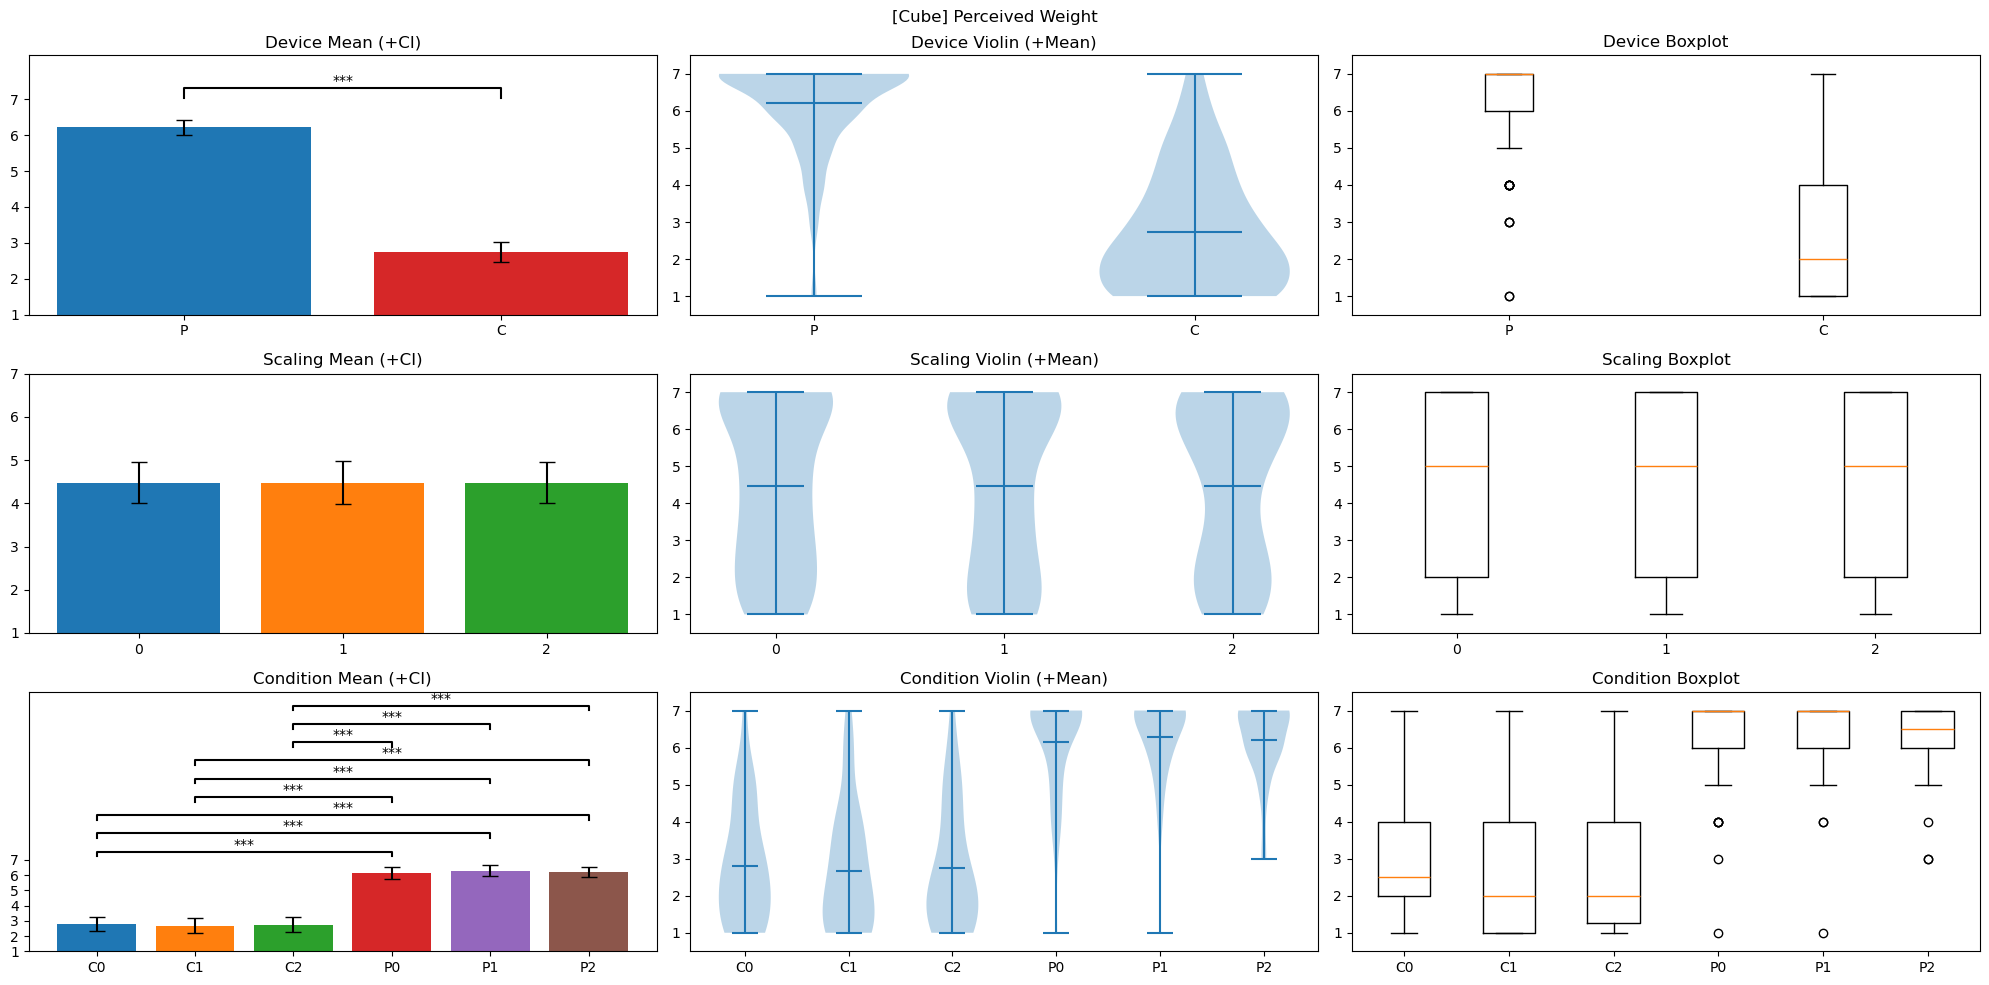

------ [Shovel] Perceived Weight: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,582.099206,1,41,582.099206,100.389741,1.385897e-12,1.385897e-12,0.457581,1.00000,✅
1,Scaling,1.579365,2,82,0.789683,1.182635,3.116421e-01,2.988463e-01,0.002284,0.69193,❌
2,Device * Scaling,0.150794,2,82,0.075397,0.107493,8.982094e-01,8.568303e-01,0.000218,0.80601,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-10.019468,41.0,two-sided,1.385897e-12,NaN,NaN,6.071e+09,-1.965267,✅


------ [Shovel] Perceived Weight: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,583.829365,5,116.765873,68.390665,8.184723e-42,7.051081e-18,0.458318,0.391843,False,0.028214,1.142320e-22,✅
1,Error,350.003968,205,1.707336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.062281,41.0,two-sided,2.943255e-01,1.000000e+00,holm,0.282,-0.094285,❌
1,Condition,C0,C2,True,True,-0.448583,41.0,two-sided,6.560942e-01,1.000000e+00,holm,0.183,-0.061661,❌
2,Condition,C0,P0,True,True,-9.180505,41.0,two-sided,1.696539e-11,2.205501e-10,holm,5.522e+08,-1.767270,✅
3,Condition,C0,P1,True,True,-10.652249,41.0,two-sided,2.223529e-13,3.335294e-12,holm,3.513e+10,-1.968914,✅
4,Condition,C0,P2,True,True,-10.583954,41.0,two-sided,2.702264e-13,3.783169e-12,holm,2.913e+10,-1.997467,✅
5,Condition,C1,C2,True,True,0.274280,41.0,two-sided,7.852469e-01,1.000000e+00,holm,0.173,0.029420,❌
6,Condition,C1,P0,True,True,-8.155614,41.0,two-sided,4.056791e-10,3.245433e-09,holm,2.676e+07,-1.616988,✅
7,Condition,C1,P1,True,True,-9.082032,41.0,two-sided,2.289455e-11,2.747346e-10,holm,4.147e+08,-1.802089,✅
8,Condition,C1,P2,True,True,-8.989781,41.0,two-sided,3.034824e-11,3.338307e-10,holm,3.168e+08,-1.826039,✅
9,Condition,C2,P0,True,True,-7.710475,41.0,two-sided,1.667433e-09,1.167203e-08,holm,6.987e+06,-1.620607,✅


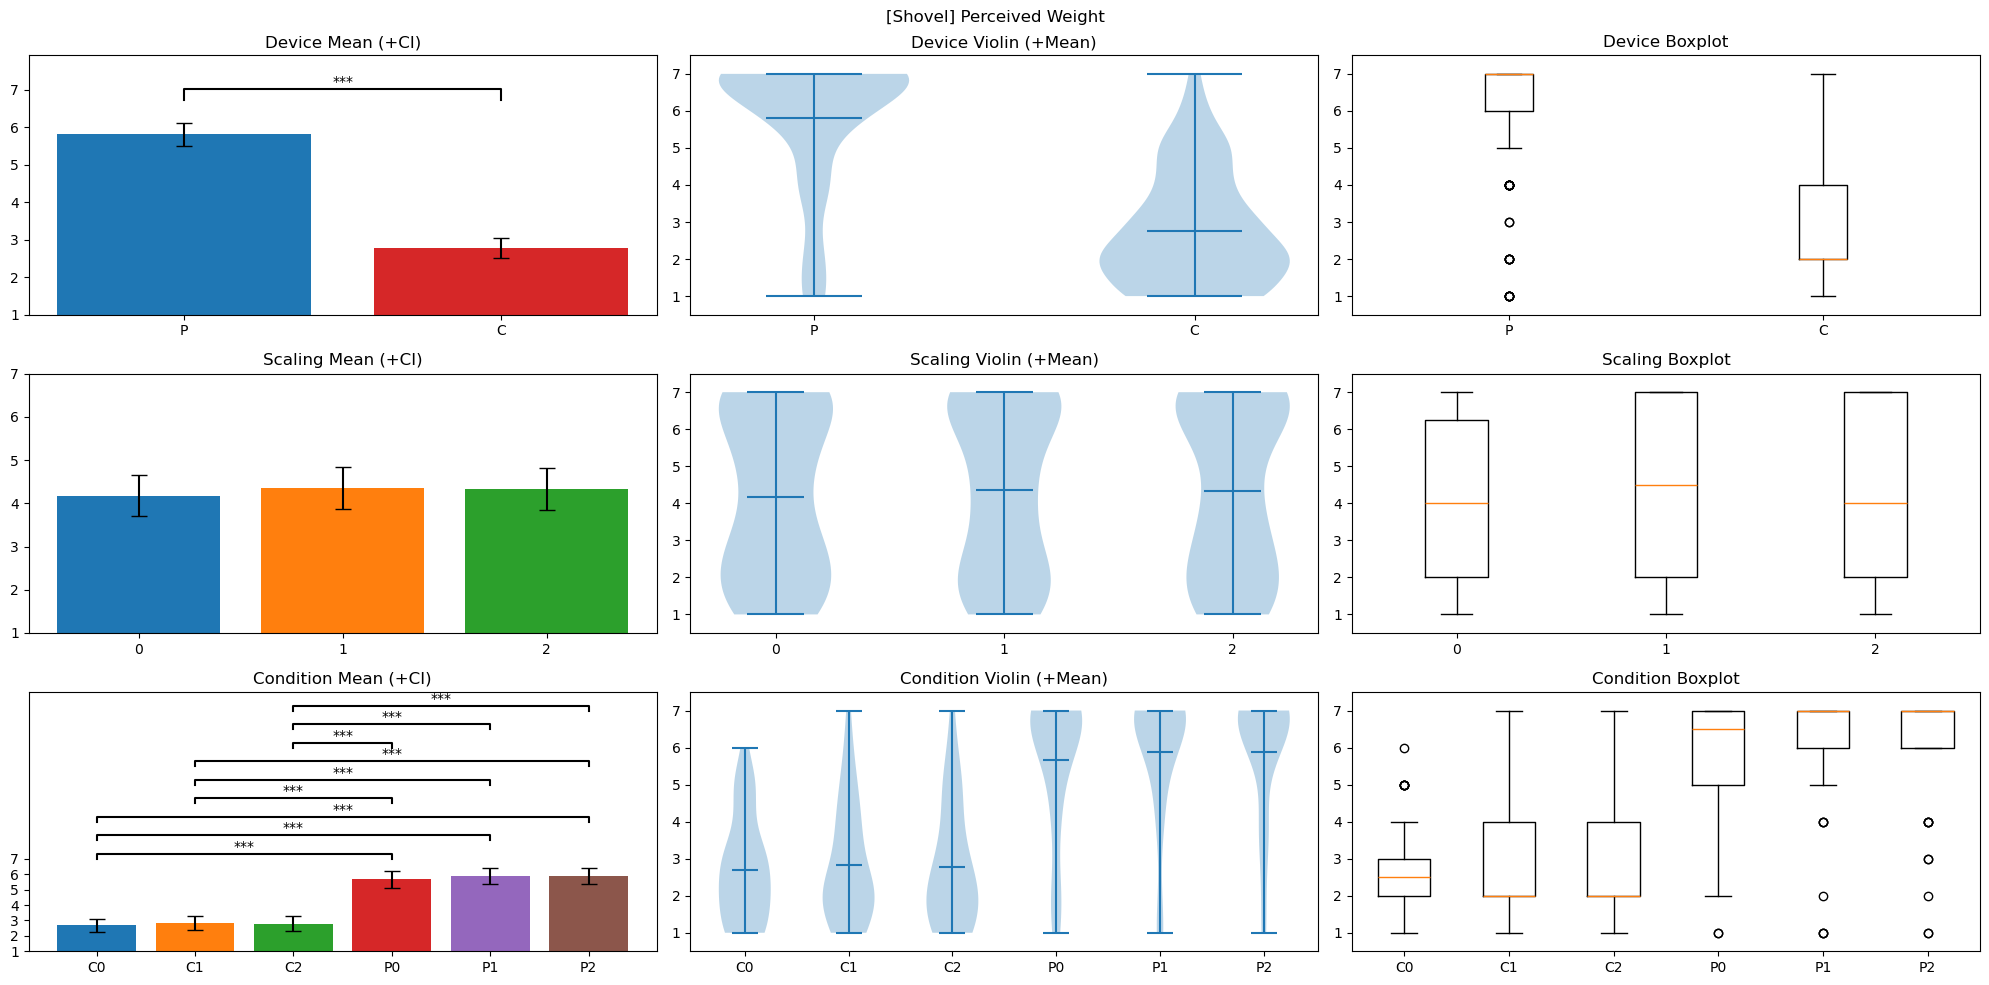

In [513]:
general_perceived_weight = 'general_perceived_weight'
data[general_perceived_weight] = data[general_1]

title = 'Perceived Weight'
score = general_perceived_weight
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Perceived Weight Realism: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,700.000000,1,41,700.000000,188.402626,6.357494e-17,6.357494e-17,0.561069,1.000000,✅
1,Scaling,0.023810,2,82,0.011905,0.011908,9.881641e-01,9.854520e-01,0.000043,0.946549,❌
2,Device * Scaling,0.071429,2,82,0.035714,0.042694,9.582263e-01,9.522768e-01,0.000130,0.948907,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-13.725984,41.0,two-sided,6.357494e-17,NaN,NaN,9.107e+13,-2.599694,✅


------ [Cube] Perceived Weight Realism: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,700.095238,5,140.019048,94.762144,2.340869e-51,1.553503e-31,0.561102,0.593902,False,0.196984,2.968079e-08,✅
1,Error,302.904762,205,1.477584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-0.208404,41.0,two-sided,8.359455e-01,1.000000e+00,holm,0.17,-0.027860,❌
1,Condition,C0,C2,True,True,-0.096432,41.0,two-sided,9.236472e-01,1.000000e+00,holm,0.168,-0.014477,❌
2,Condition,C0,P0,True,True,-11.459031,41.0,two-sided,2.325631e-14,2.558194e-13,holm,3.077e+11,-2.270362,✅
3,Condition,C0,P1,True,True,-11.543614,41.0,two-sided,1.844441e-14,2.332437e-13,holm,3.846e+11,-2.311981,✅
4,Condition,C0,P2,True,True,-12.662353,41.0,two-sided,9.365126e-16,1.404769e-14,holm,6.79e+12,-2.287736,✅
5,Condition,C1,C2,True,True,0.099312,41.0,two-sided,9.213745e-01,1.000000e+00,holm,0.168,0.013770,❌
6,Condition,C1,P0,True,True,-10.823255,41.0,two-sided,1.368203e-13,1.231383e-12,holm,5.6e+10,-2.107032,✅
7,Condition,C1,P1,True,True,-10.757714,41.0,two-sided,1.647342e-13,1.317873e-12,holm,4.686e+10,-2.139142,✅
8,Condition,C1,P2,True,True,-9.774776,41.0,two-sided,2.851220e-12,1.995854e-11,holm,3.042e+09,-2.117352,✅
9,Condition,C2,P0,True,True,-11.095561,41.0,two-sided,6.364111e-14,6.364111e-13,holm,1.169e+11,-2.220430,✅


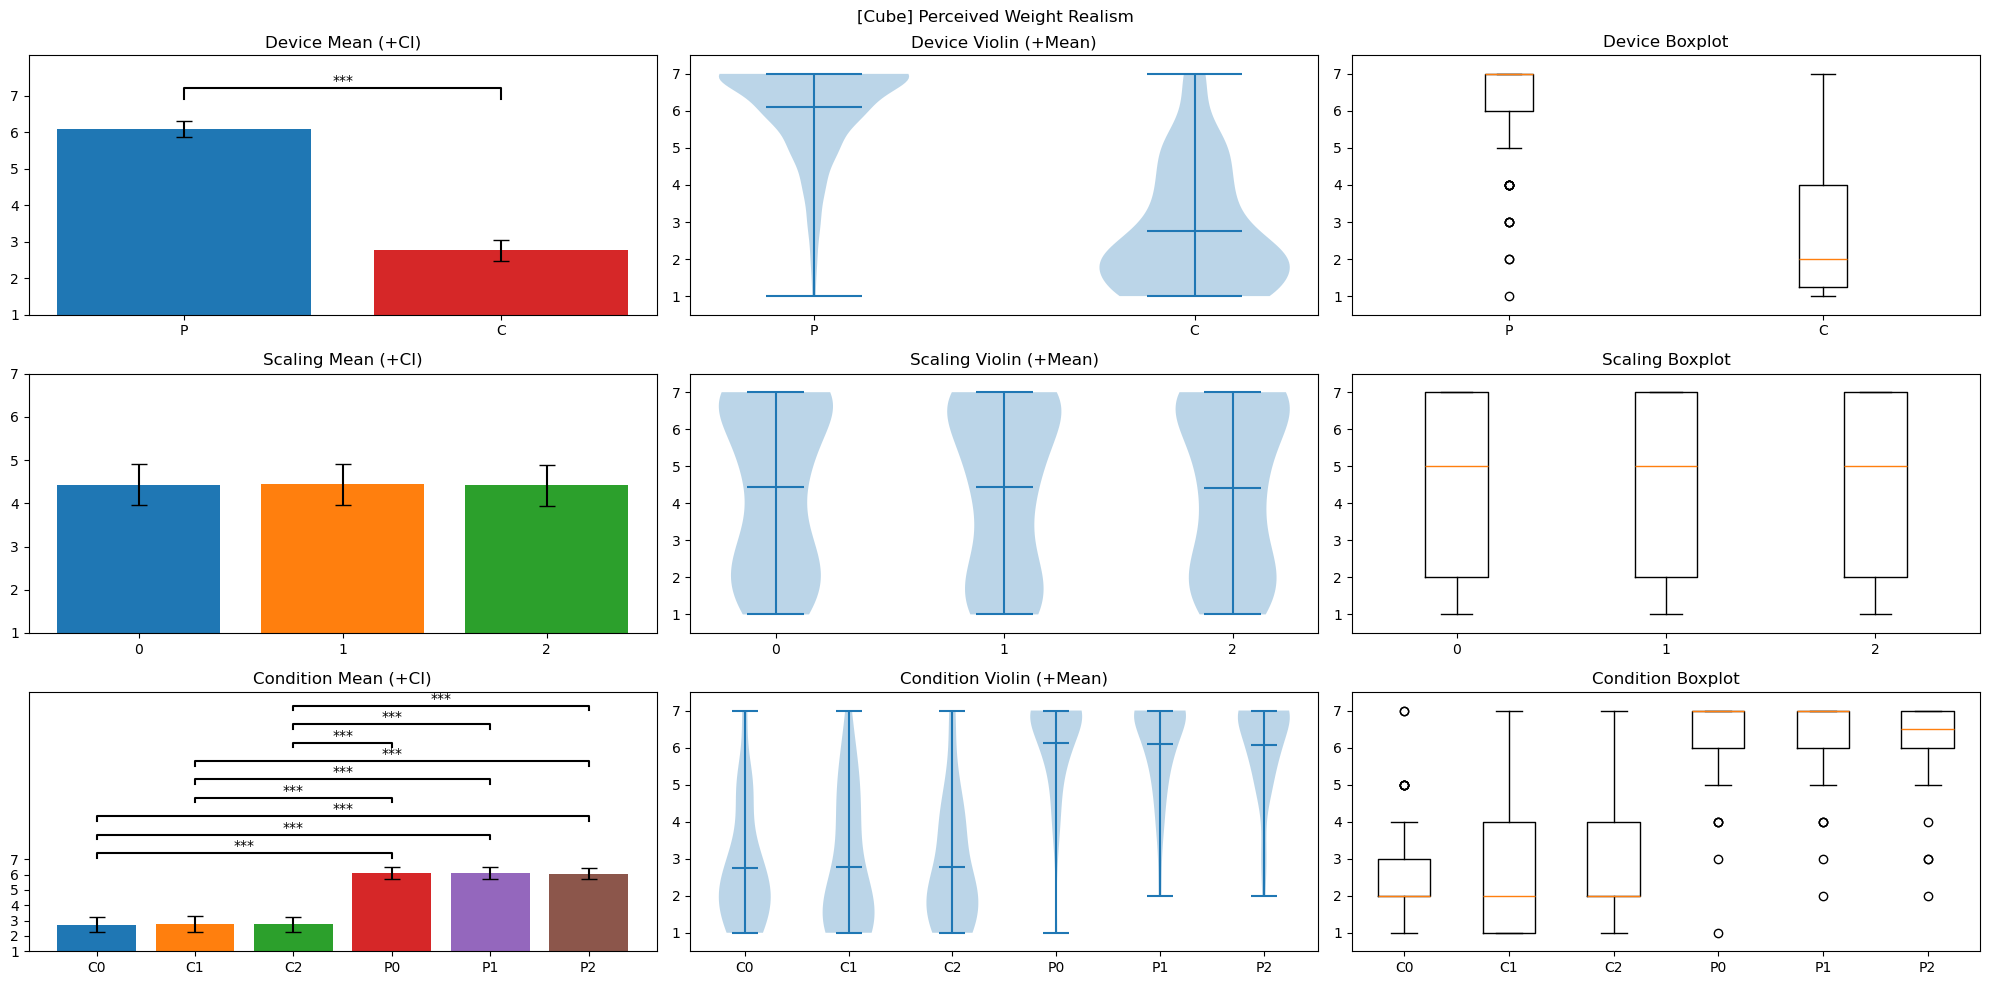

------ [Shovel] Perceived Weight Realism: Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,609.777778,1,41,609.777778,109.227184,3.954738e-13,3.954738e-13,0.475551,1.000000,✅
1,Scaling,2.214286,2,82,1.107143,1.501772,2.287965e-01,2.311220e-01,0.003282,0.805989,❌
2,Device * Scaling,0.388889,2,82,0.194444,0.261623,7.704416e-01,7.702826e-01,0.000578,0.999269,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-10.451181,41.0,two-sided,3.954738e-13,NaN,NaN,2.021e+10,-2.059554,✅


------ [Shovel] Perceived Weight Realism: One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,612.380952,5,122.476190,71.677542,4.038983e-43,6.254046e-20,0.476614,0.42948,False,0.059353,5.445041e-17,✅
1,Error,350.285714,205,1.708711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-1.102338,41.0,two-sided,2.767438e-01,1.000000e+00,holm,0.294,-0.130639,❌
1,Condition,C0,C2,True,True,0.520648,41.0,two-sided,6.054125e-01,1.000000e+00,holm,0.19,0.064665,❌
2,Condition,C0,P0,True,True,-9.230742,41.0,two-sided,1.456649e-11,1.747978e-10,holm,6.388e+08,-1.851037,✅
3,Condition,C0,P1,True,True,-10.504836,41.0,two-sided,3.389712e-13,5.084568e-12,holm,2.344e+10,-1.995605,✅
4,Condition,C0,P2,True,True,-8.922998,41.0,two-sided,3.724079e-11,2.979263e-10,holm,2.606e+08,-1.850556,✅
5,Condition,C1,C2,True,True,1.546540,41.0,two-sided,1.296592e-01,7.779551e-01,holm,0.5,0.196878,❌
6,Condition,C1,P0,True,True,-9.001140,41.0,two-sided,2.931157e-11,2.638041e-10,holm,3.275e+08,-1.636615,✅
7,Condition,C1,P1,True,True,-9.485965,41.0,two-sided,6.746244e-12,8.770117e-11,holm,1.334e+09,-1.764891,✅
8,Condition,C1,P2,True,True,-8.489094,41.0,two-sided,1.425575e-10,9.979026e-10,holm,7.243e+07,-1.638376,✅
9,Condition,C2,P0,True,True,-9.169462,41.0,two-sided,1.754430e-11,1.863828e-10,holm,5.348e+08,-1.987355,✅


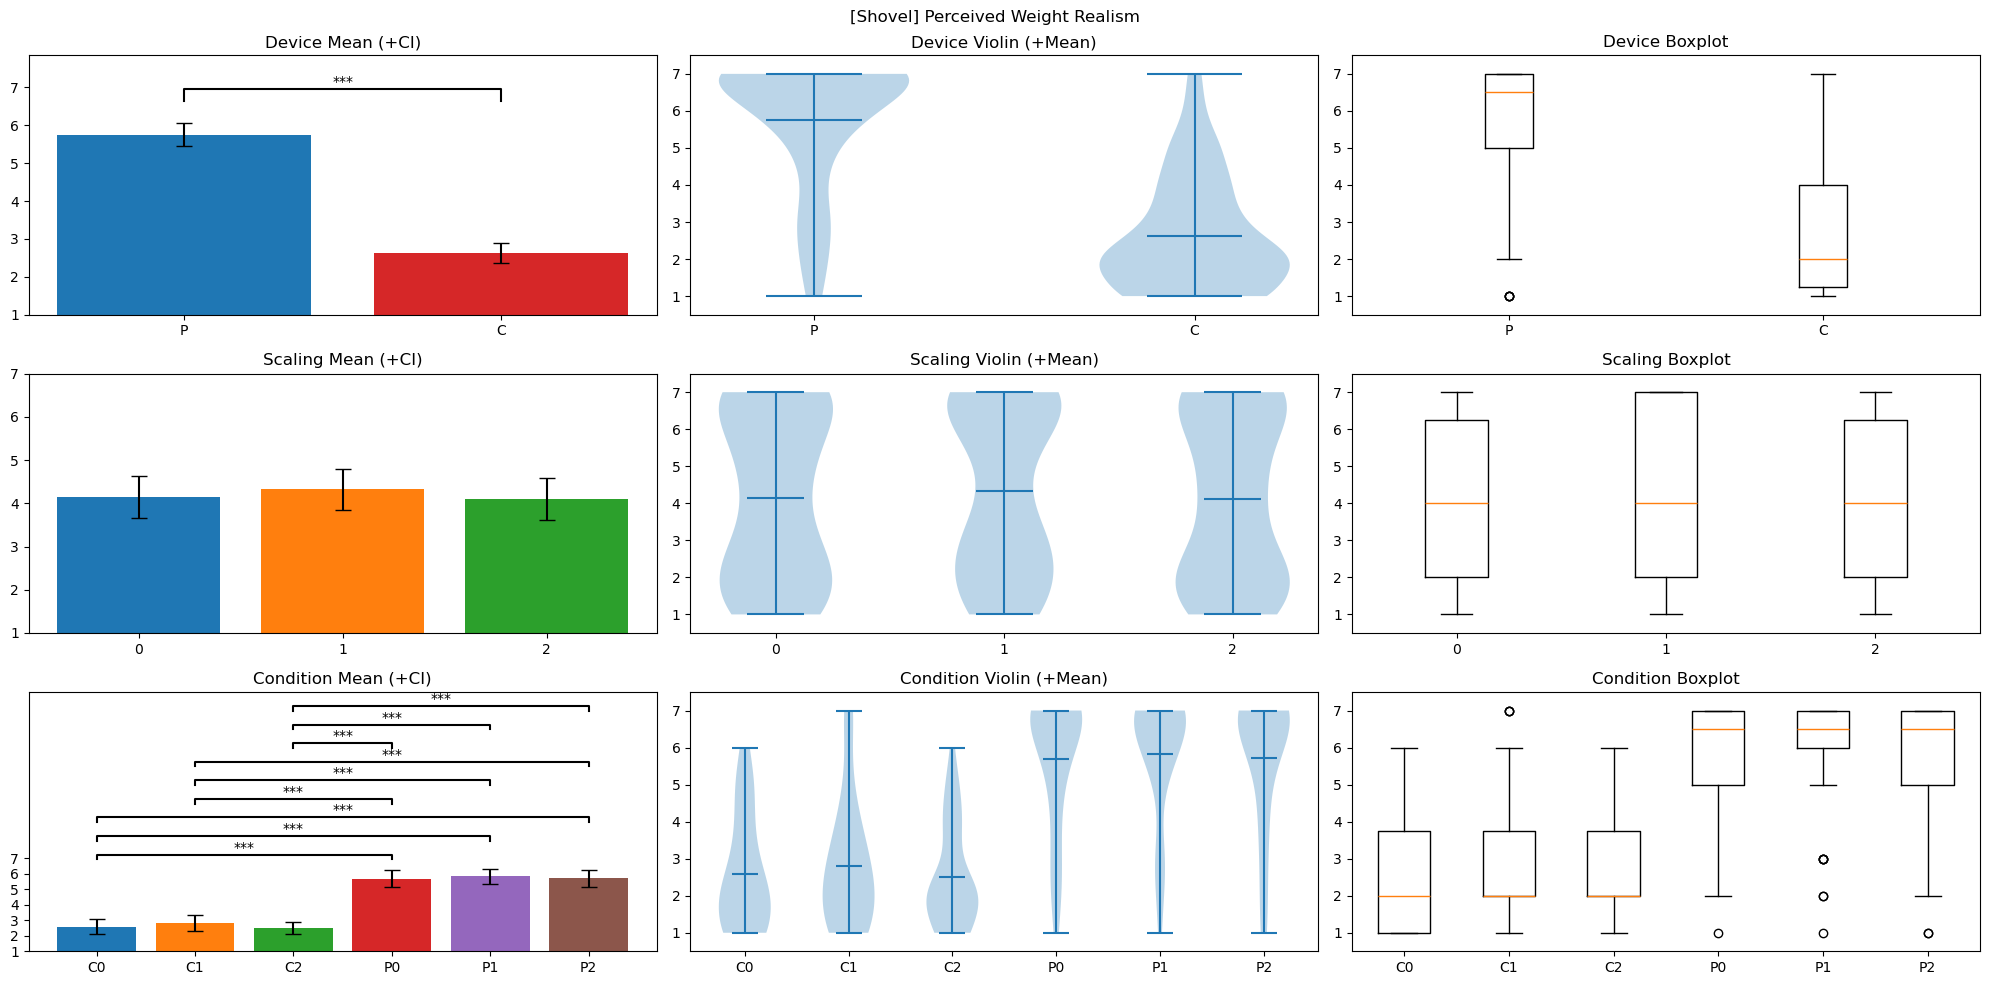

In [514]:
general_perceived_weight_realism = 'general_perceived_weight_realism'
data[general_perceived_weight_realism] = data[general_2]

title = 'Perceived Weight Realism'
score = general_perceived_weight_realism
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Shovel] Perceived weight increase (Load): Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.194444,1,41,0.194444,0.116714,0.734371,0.734371,0.000319,1.000000,❌
1,Scaling,6.380952,2,82,3.190476,5.380999,0.006371,0.013779,0.010375,0.720851,✅
2,Device * Scaling,2.031746,2,82,1.015873,1.773572,0.176174,0.180247,0.003327,0.895166,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.238722,41.0,two-sided,0.222494,0.222494,holm,0.34,-0.089745,❌
2,Scaling,-,0,2,True,True,-2.518332,41.0,two-sided,0.015789,0.039761,holm,2.717,-0.262031,✅
3,Scaling,-,1,2,True,True,-2.589219,41.0,two-sided,0.013254,0.039761,holm,3.151,-0.174397,✅


------ [Shovel] Perceived weight increase (Load): One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,8.607143,5,1.721429,2.153192,0.060627,0.092163,0.013944,0.643094,False,0.210841,8.717158e-08,🟨
1,Error,163.892857,205,0.799477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


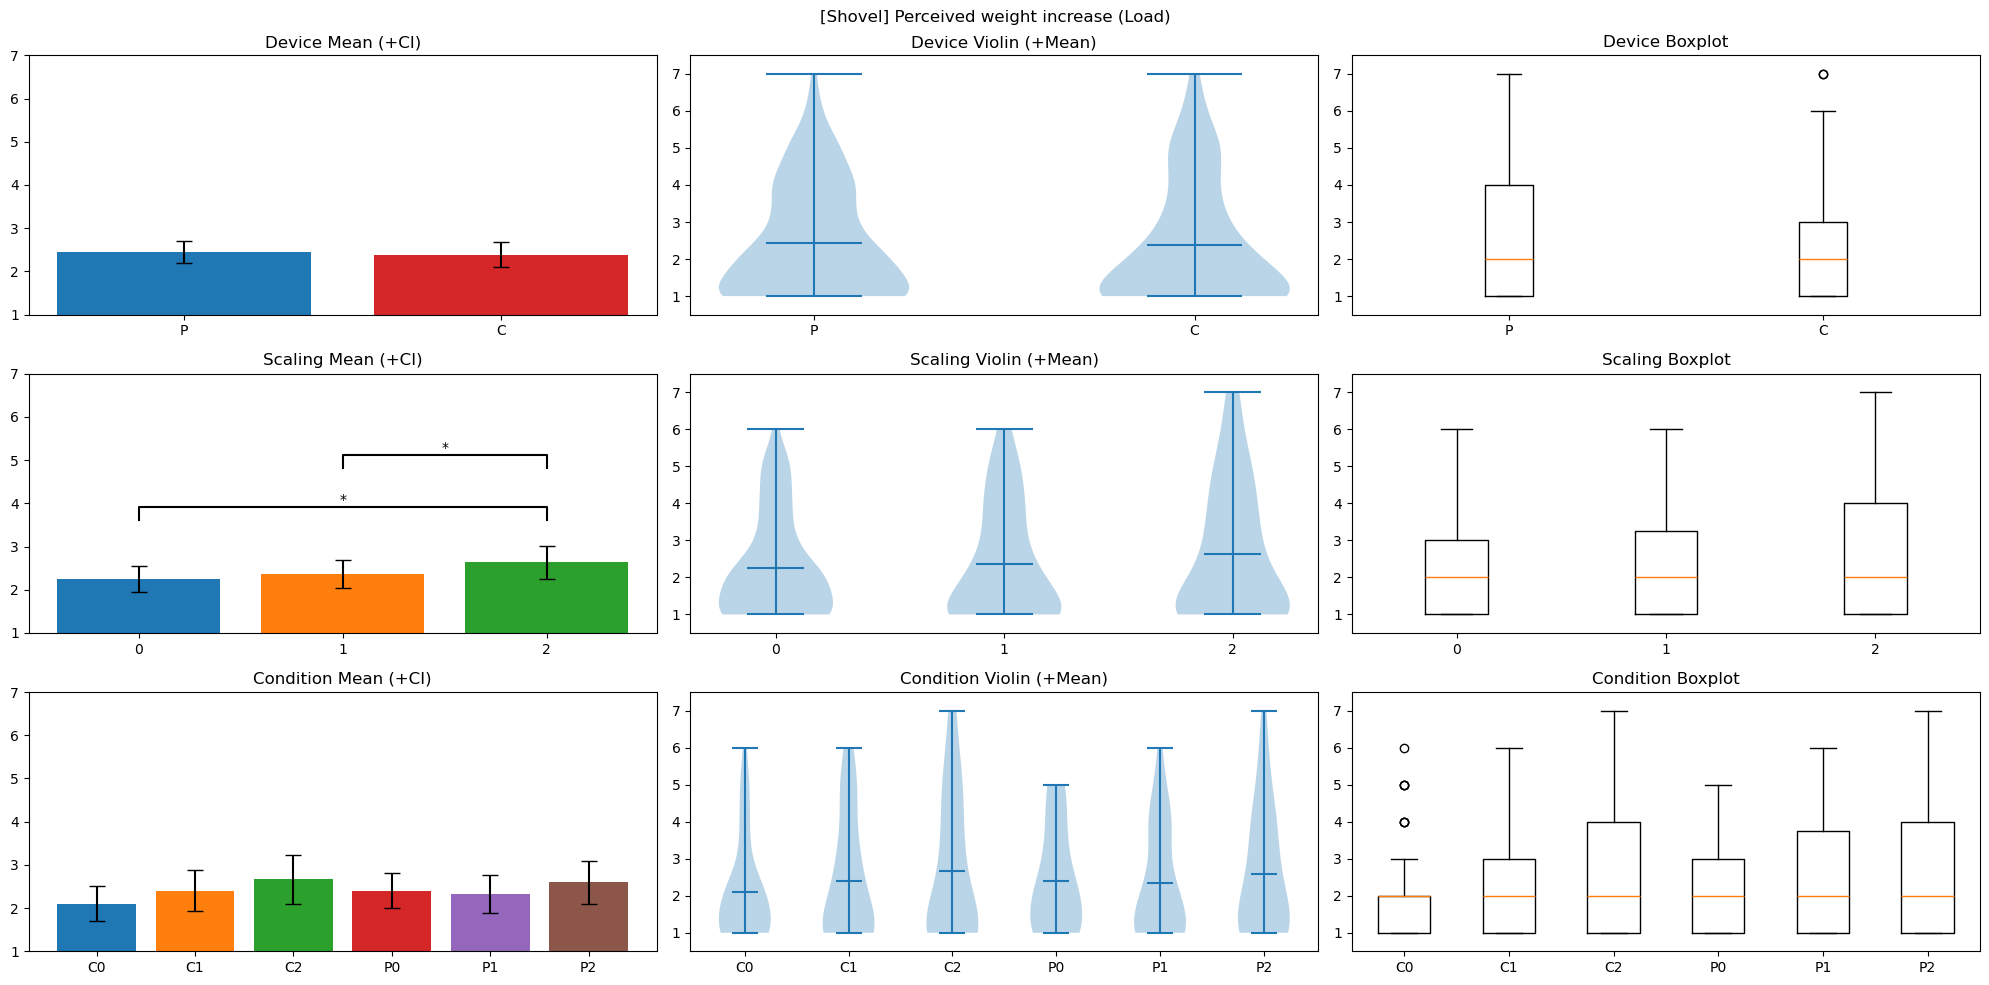

------ [Shovel] Perceived weight decrease (Unload): Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.015873,1,41,0.015873,0.011625,0.914666,0.914666,0.000027,1.000000,❌
1,Scaling,5.484127,2,82,2.742063,4.799424,0.010688,0.016689,0.009276,0.808341,✅
2,Device * Scaling,1.388889,2,82,0.694444,1.023976,0.363710,0.360663,0.002366,0.948589,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.357271,41.0,two-sided,0.182120,0.182120,holm,0.391,-0.098663,❌
2,Scaling,-,0,2,True,True,-2.517977,41.0,two-sided,0.015803,0.047408,holm,2.715,-0.252327,✅
3,Scaling,-,1,2,True,True,-2.120067,41.0,two-sided,0.040098,0.080197,holm,1.254,-0.155182,🟨


------ [Shovel] Perceived weight decrease (Unload): One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,6.888889,5,1.377778,1.782609,0.117818,0.138997,0.011625,0.753551,False,0.363027,0.000299,❌
1,Error,158.444444,205,0.772900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


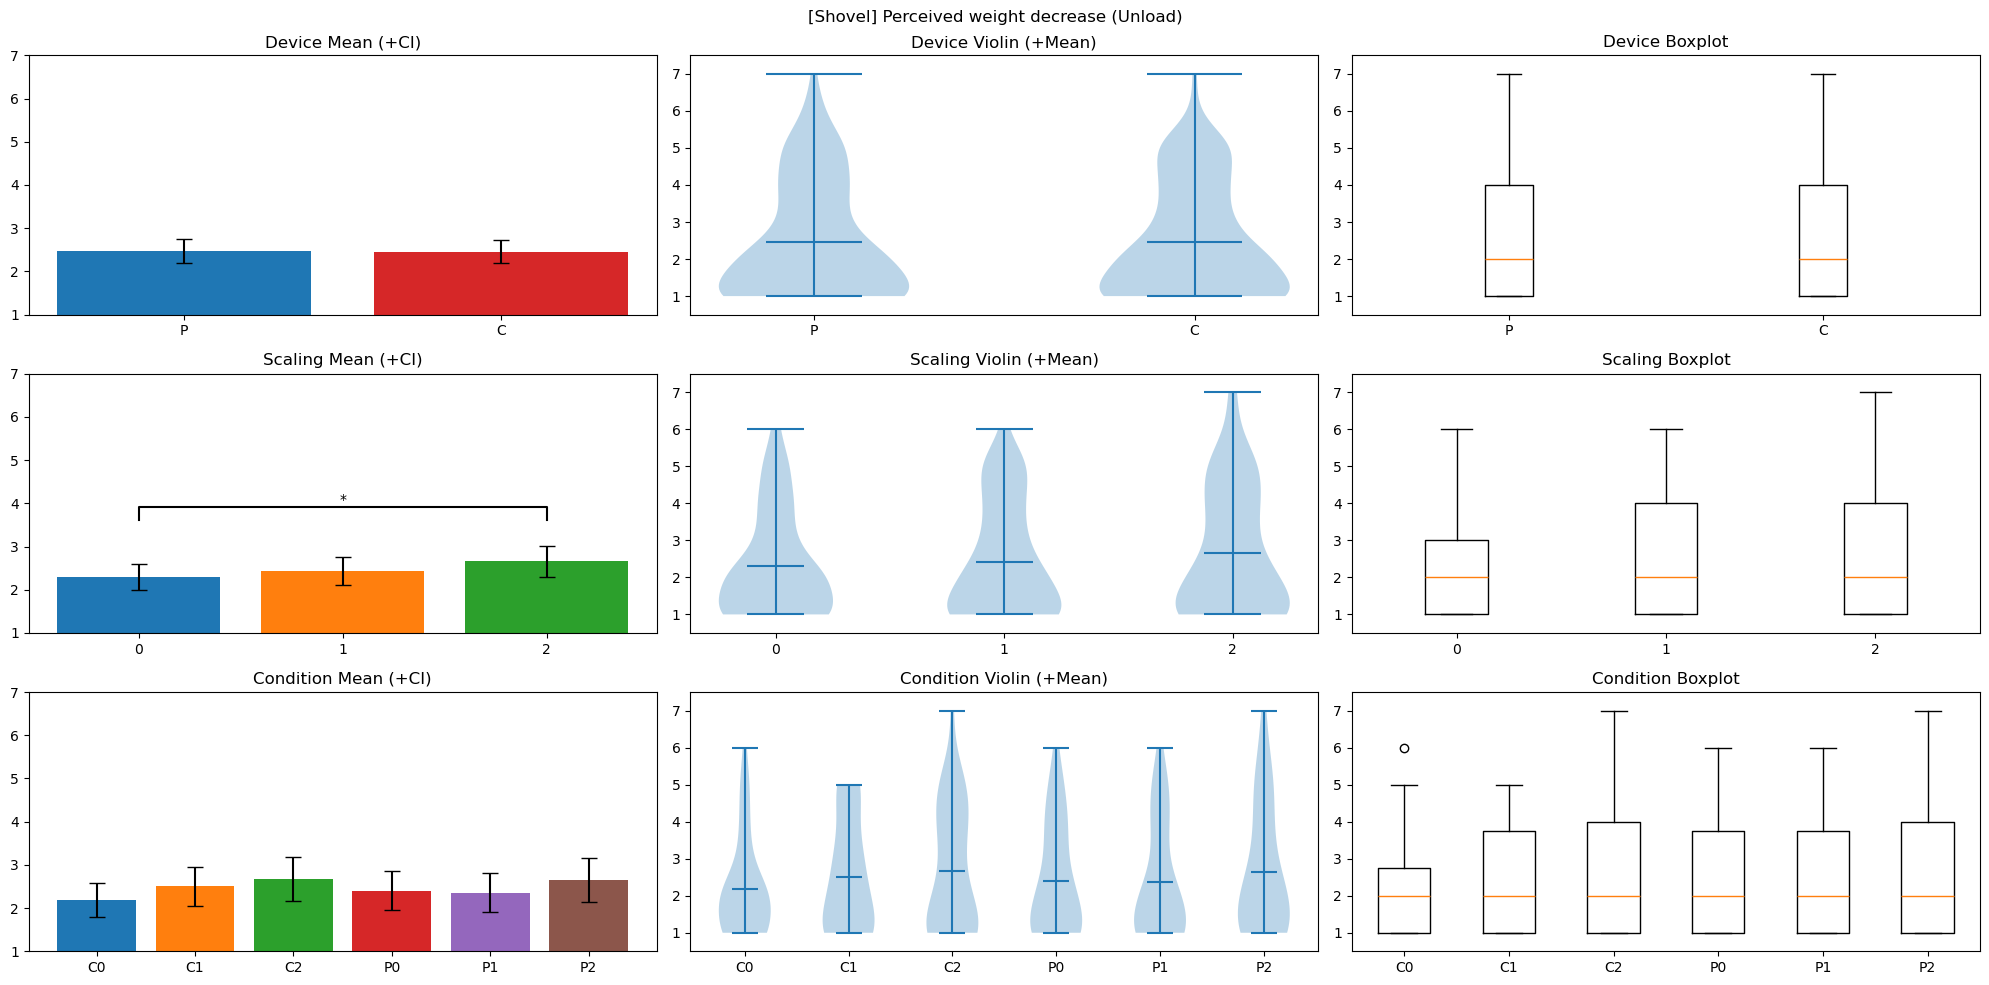

------ [Shovel] Perceived effort increase (Load): Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.587302,1,41,1.587302,0.637537,0.429205,0.429205,0.002037,1.000000,❌
1,Scaling,22.952381,2,82,11.476190,7.926996,0.000712,0.001336,0.028665,0.865239,✅
2,Device * Scaling,0.412698,2,82,0.206349,0.188173,0.828828,0.802026,0.000530,0.882883,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.372547,41.0,two-sided,0.022439,0.044878,holm,2.023,-0.277102,✅
2,Scaling,-,0,2,True,True,-3.369682,41.0,two-sided,0.001649,0.004947,holm,19.29,-0.480742,✅
3,Scaling,-,1,2,True,True,-2.054407,41.0,two-sided,0.046348,0.046348,holm,1.115,-0.199723,✅


------ [Shovel] Perceived effort increase (Load): One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,24.952381,5,4.990476,3.292567,0.006988,0.014436,0.031085,0.754058,False,0.369437,0.000381,✅
1,Error,310.714286,205,1.515679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-2.049390,41.0,two-sided,0.046859,0.515444,holm,1.105,-0.288197,❌
1,Condition,C0,C2,True,True,-2.619357,41.0,two-sided,0.012294,0.159817,holm,3.359,-0.445023,❌
2,Condition,C0,P0,True,True,0.233034,41.0,two-sided,0.816895,1.000000,holm,0.171,0.032461,❌
3,Condition,C0,P1,True,True,-0.967764,41.0,two-sided,0.338836,1.000000,holm,0.258,-0.155100,❌
4,Condition,C0,P2,True,True,-2.126698,41.0,two-sided,0.039510,0.474124,holm,1.269,-0.345859,❌
5,Condition,C1,C2,True,True,-1.346625,41.0,two-sided,0.185498,1.000000,holm,0.386,-0.157003,❌
6,Condition,C1,P0,True,True,2.037401,41.0,two-sided,0.048099,0.515444,holm,1.082,0.331459,❌
7,Condition,C1,P1,True,True,0.836171,41.0,two-sided,0.407906,1.000000,holm,0.231,0.128577,❌
8,Condition,C1,P2,True,True,-0.408281,41.0,two-sided,0.685192,1.000000,holm,0.18,-0.061221,❌
9,Condition,C2,P0,True,True,2.703133,41.0,two-sided,0.009950,0.139306,holm,4.024,0.492529,❌


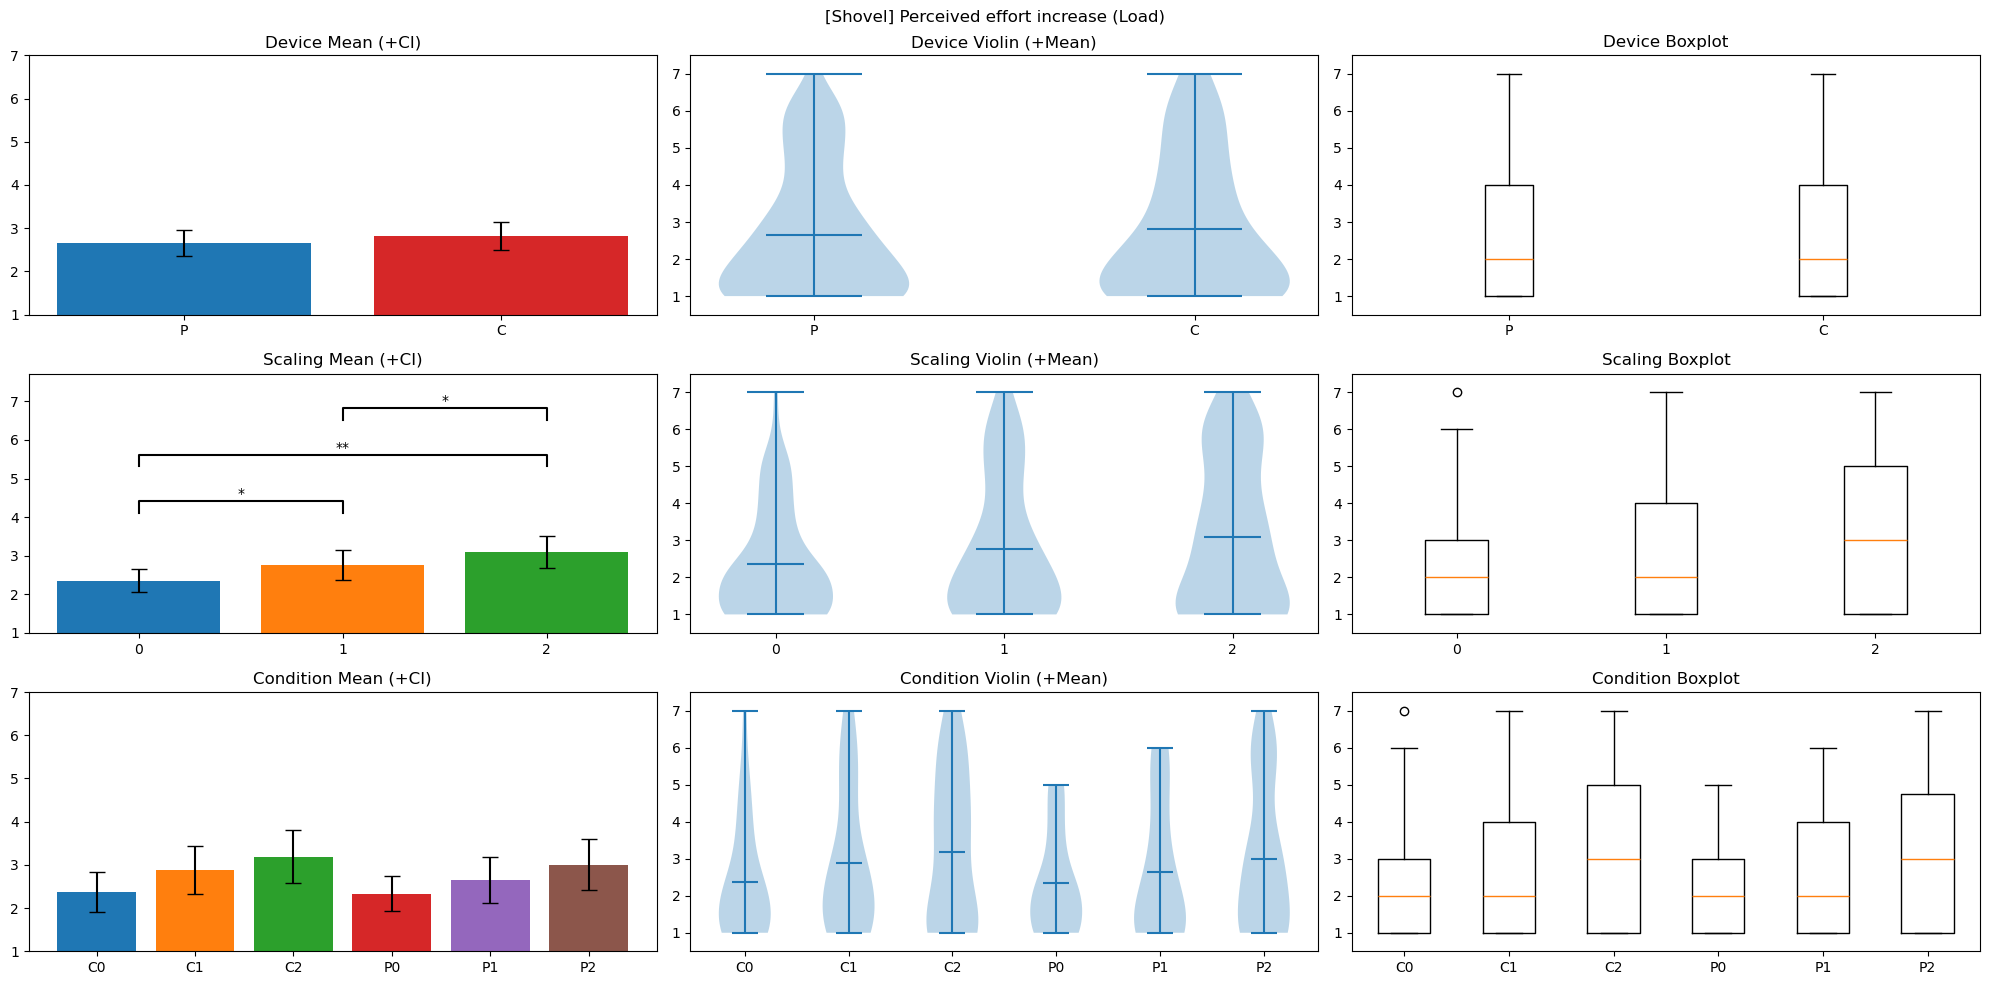

------ [Shovel] Perceived effort decrease (Unload): Two-Way RM ANOVA ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,3.571429,1,41,3.571429,1.380162,0.246852,0.246852,0.005260,1.000000,❌
1,Scaling,20.023810,2,82,10.011905,7.182045,0.001336,0.003462,0.028794,0.768635,✅
2,Device * Scaling,0.880952,2,82,0.440476,0.432810,0.650157,0.639074,0.001303,0.945531,❌


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.363425,41.0,two-sided,0.022929,0.045858,holm,1.987,-0.267371,✅
2,Scaling,-,0,2,True,True,-3.054799,41.0,two-sided,0.003948,0.011844,holm,8.949,-0.477342,✅
3,Scaling,-,1,2,True,True,-2.095425,41.0,two-sided,0.042351,0.045858,holm,1.199,-0.228872,✅


------ [Shovel] Perceived effort decrease (Unload): One-Way RM ANOVA ------


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher,Significance
0,Condition,24.476190,5,4.895238,3.302617,0.006853,0.015724,0.034973,0.720444,False,0.338742,0.000113,✅
1,Error,303.857143,205,1.482230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,❌


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Condition,C0,C1,True,True,-2.124951,41.0,two-sided,0.039664,0.396645,holm,1.265,-0.310742,❌
1,Condition,C0,C2,True,True,-2.528734,41.0,two-sided,0.015391,0.215474,holm,2.777,-0.464622,❌
2,Condition,C0,P0,True,True,0.342751,41.0,two-sided,0.733537,1.000000,holm,0.176,0.051167,❌
3,Condition,C0,P1,True,True,-0.557320,41.0,two-sided,0.580339,1.000000,holm,0.193,-0.091465,❌
4,Condition,C0,P2,True,True,-1.669254,41.0,two-sided,0.102687,0.901666,holm,0.596,-0.299537,❌
5,Condition,C1,C2,True,True,-1.299321,41.0,two-sided,0.201093,1.000000,holm,0.364,-0.183507,❌
6,Condition,C1,P0,True,True,2.182584,41.0,two-sided,0.034849,0.383343,holm,1.406,0.368152,❌
7,Condition,C1,P1,True,True,1.180341,41.0,two-sided,0.244668,1.000000,holm,0.319,0.202738,❌
8,Condition,C1,P2,True,True,-0.080411,41.0,two-sided,0.936302,1.000000,holm,0.167,-0.013633,❌
9,Condition,C2,P0,True,True,2.768151,41.0,two-sided,0.008424,0.126362,holm,4.641,0.517318,❌


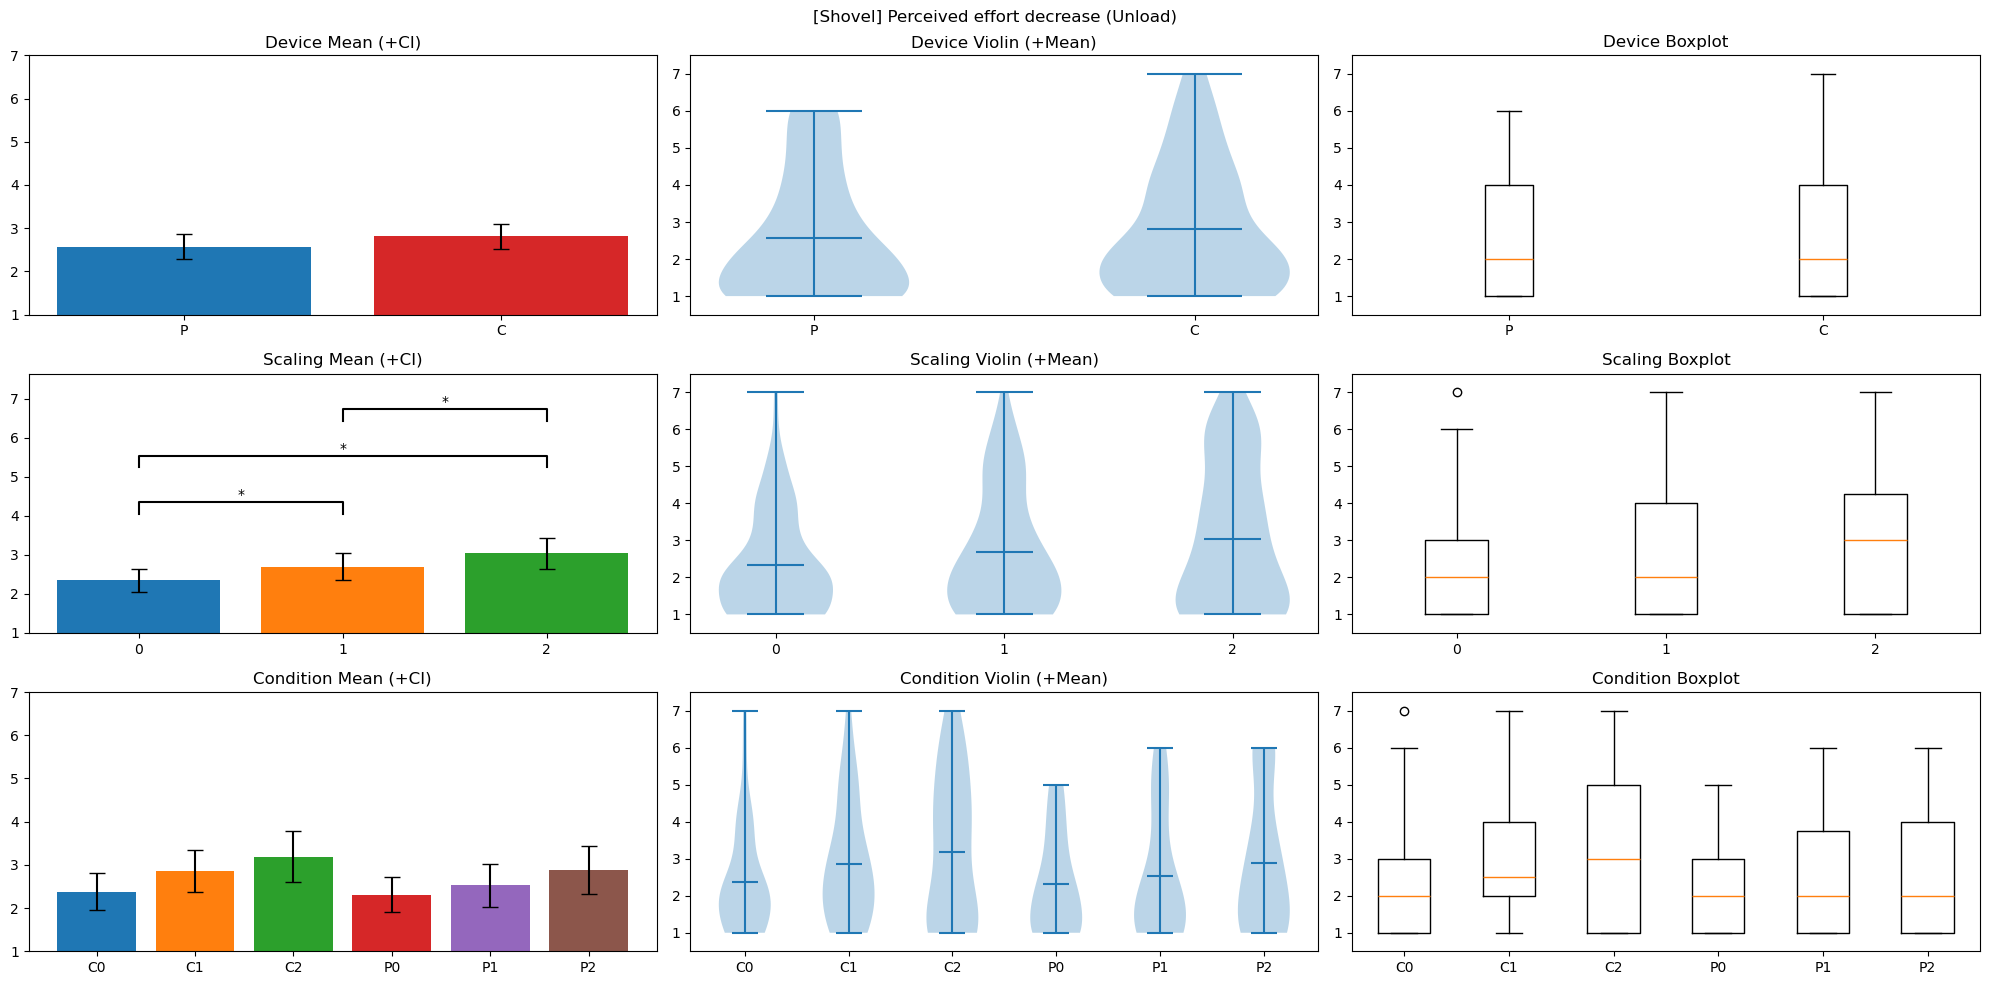

In [515]:
scale = [1,7]

shovel_load_weight = 'shovel_load_weight'
data[shovel_load_weight] = data[shovel_1]
report_exeriment(data, shovel, shovel_load_weight, 'Perceived weight increase (Load)', scale)

shovel_unload_weight = 'shovel_unload_weight'
data[shovel_unload_weight] = data[shovel_2]
report_exeriment(data, shovel, shovel_unload_weight, 'Perceived weight decrease (Unload)', scale)

shovel_load_effort = 'shovel_load_effort'
data[shovel_load_effort] = data[shovel_3]
report_exeriment(data, shovel, shovel_load_effort, 'Perceived effort increase (Load)', scale)

shovel_unload_effort = 'shovel_unload_effort'
data[shovel_unload_effort] = data[shovel_4]
report_exeriment(data, shovel, shovel_unload_effort, 'Perceived effort decrease (Unload)', scale)

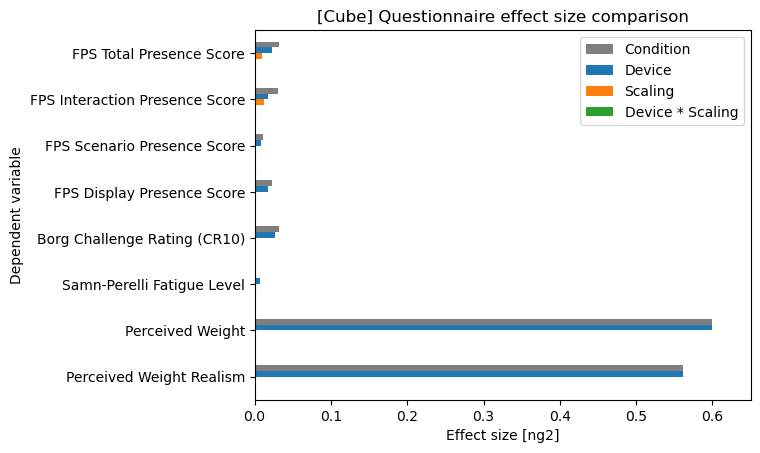

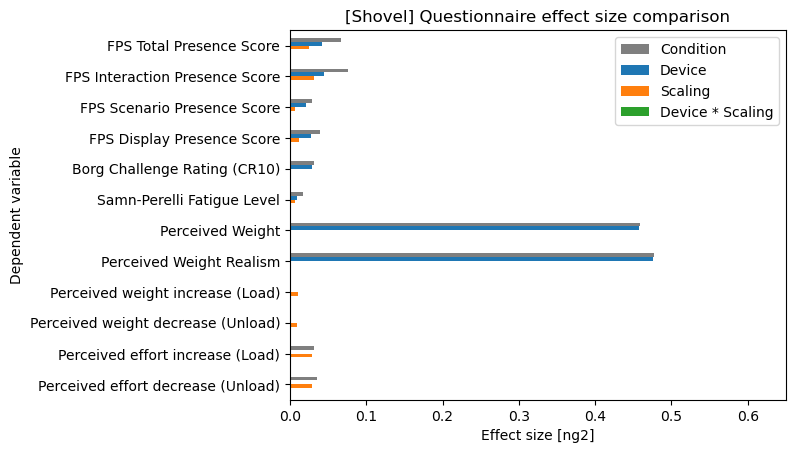

In [522]:
columns = [condition_key, device_key, scaling_key, device_x_scaling_key]
eff_size_colors = ["tab:gray", "tab:blue", "tab:orange", "tab:green"]

def get_aov_eff_sizes(entry):
    eff_sizes = []

    one_way = entry[one_way_key]
    row = one_way.iloc[0] #Second row is error entry
    if row[significance_key] == "✅":
        eff_sizes.append(row[eff_size_key])
    else:
        eff_sizes.append(0)

    two_way = entry[two_way_key]
    for index, row in two_way.iterrows():
        if row[significance_key] == "✅":
            eff_sizes.append(row[eff_size_key])
        else:
            eff_sizes.append(0)

    return eff_sizes

cube_aov_index = list(map(lambda x: x[aovs_dv_key], cube_aovs))
cube_aov_values = list(map(lambda x: get_aov_eff_sizes(x), cube_aovs))
cube_df = pd.DataFrame(cube_aov_values, columns=columns, index = cube_aov_index)
cube_df.plot(kind='barh', color=eff_size_colors)
plt.title("[Cube] Questionnaire effect size comparison")
plt.xlabel("Effect size [" + eff_size_key + "]")
plt.ylabel("Dependent variable")
plt.xlim([0,0.65])
plt.gca().invert_yaxis()
plt.show()

shovel_aov_index = list(map(lambda x: x[aovs_dv_key], shovel_aovs))
shovel_aov_values = list(map(lambda x: get_aov_eff_sizes(x), shovel_aovs))
shovel_df = pd.DataFrame(shovel_aov_values, columns=columns, index = shovel_aov_index)
shovel_df.plot(kind='barh', color=eff_size_colors)
plt.title("[Shovel] Questionnaire effect size comparison")
plt.xlabel("Effect size [" + eff_size_key + "]")
plt.ylabel("Dependent variable")
plt.xlim([0,0.65])
plt.gca().invert_yaxis()
plt.show()